# Lesson 120 · Year 3 exit exam: a heterogeneous temporal GNN

Teacher reference · Five live functions feed a real PyG training pipeline. Default: small authored training plus rescoring embedded full-data author predictions. Full GPU training remains a separate gate. Learner status PENDING_WRITTEN_DEFENSE.

In [1]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


Actual notebook runtime: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'pytorch-frame': '0.3.0', 'torch-geometric': '2.8.0.post1', 'relbench': '1.1.0'}


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 119 to this lesson</p>
<p>The synthesis made a conditional argument for relational learning. The exam asks you to make the supporting graph, clock, training and evaluation contracts executable.</p>
<details><summary>Quick prerequisite reminder</summary><p>Query identity includes entity and cutoff. Local tensor position, database row identity and query ownership are different indices. Context rows can receive gradients without receiving direct labels.</p></details>
</aside>
<!-- sequence-review:end -->

<p class="stream-kicker">Year 3 exit · from assembled parts to a defensible system</p>

**Your win:** build and defend a heterogeneous, temporal PyG predictor whose graph, batches, training labels and reported score refer to the same legal prediction questions.

[Student notebook](https://avistian.github.io/relational/labs/0120-year-3-exit-exam.ipynb) · [Executed reference](https://avistian.github.io/relational/labs/html/0120-year-3-exit-exam.html) · [Exam submission](https://avistian.github.io/relational/labs/l120-submission.md) · [Quick reference](https://avistian.github.io/relational/reference/year-3-exit-exam.html) · [Full reproduction contract](https://avistian.github.io/relational/labs/l120-reproduction.md)

This is a deliverable-based exam. Start with the closed-notes questions, then implement the five functions in the notebook. Consult the worked explanation when stuck; record the assistance in your submission. Plan several one-hour sessions for implementation, full-paper reading, execution and defense. Finishing this page is not the Year 3 exit criterion.



## 1 · Retrieve the contracts before writing code

Without opening previous lessons, answer these questions:

1. Why does a foreign key equal to 90 not necessarily point to row 90?
2. A result occurred on day 5 and arrived on day 8. Can a day-7 prediction use it?
3. The same person appears in two queries at different times. Must their sampled graphs be identical?
4. Which nodes receive the supervised loss in a sampled batch? Which may still receive gradients indirectly?
5. What evidence would establish that your code ran, and what additional evidence establishes that you understand it?

<details><summary>Check the contracts after attempting retrieval</summary><p>Primary keys identify entities; array positions identify storage locations. Day-7 queries cannot use a day-8 arrival. Query identity includes entity and cutoff, so repeated entities can have different legal neighborhoods. Supervise query roots only; context representations can receive gradients through their messages. Executed artifacts establish reference behavior; an independently produced graph, implementation, leakage explanation and written defense establish learner performance.</p></details>

[Lesson 100](https://avistian.github.io/relational/lessons/0100-heterogeneous-gnn-checkpoint.html) supplies heterogeneous graph discipline; [Lesson 110](https://avistian.github.io/relational/lessons/0110-temporal-gnn-checkpoint.html) supplies time discipline; [Lesson 116](https://avistian.github.io/relational/lessons/0116-debug-gnn-training.html) supplies diagnostic discipline. [Lesson 119](https://avistian.github.io/relational/lessons/0119-year-3-synthesis.html) asks what the resulting evidence actually supports. This exam joins those contracts.



## 2 · Draw the relational entity graph by hand

A relational entity graph (REG) gives each table row its own node and each valid primary/foreign-key match its own typed edge. Reverse edges permit information to flow in the opposite direction; they do not add a second database fact. This is the construction in [Fey §3](https://proceedings.mlr.press/v235/fey24a.html).

Our small course database has three people with keys `[90,10,70]`, two merchants with keys `[8,4]`, and six event rows:

| Event row | Person key | Merchant key | Event day | Available day | Amount |
|---|---:|---:|---:|---:|---:|
| 0 | 10 | 8 | 2 | 2 | 1 |
| 1 | 90 | 8 | 3 | 3 | 2 |
| 2 | 90 | 4 | 5 | 8 | 4 |
| 3 | 10 | 4 | 9 | 9 | 8 |
| 4 | 70 | 8 | 4 | 4 | 3 |
| 5 | 90 | 4 | 11 | 11 | 16 |

Draw all eleven nodes first. Label table types and write the forward and reverse edge types. Then circle the two-hop neighborhood for `(person90, day7)`. Person and merchant attributes are immutable in this authored fixture; real changing dimension attributes need version/availability histories too.

**Worked trace:** person90 maps to person row0. Its event1 is legal at day7, event2 is late, and event5 is future. The two-hop graph therefore contains person90, event1 and merchant8. The event0 belonging to person10 is a third hop away through merchant8. At day8, event2 and merchant4 enter the graph. Neither a longer path nor a timeless merchant authorizes a future event.

**TODO 1 — `key_edges`:** map foreign keys into row positions; reject duplicate primary keys and dangling references. A missing foreign key creates no edge. The CHECK deliberately uses keys that differ from row positions.



## 3 · Preserve the query boundary through extraction and batching

For a query at time `t`, each event must satisfy `event_time ≤ t` **and** `available_time ≤ t`. We remove illegal events before traversal, then apply the hop budget to this legal graph. The root cutoff stays fixed throughout traversal. This course contract explicitly adds availability time; the released F1 benchmark lacks real ingestion histories, so its timestamps cannot prove that every historical feature was actually available. [Fey §3.3 and appendices](https://proceedings.mlr.press/v235/fey24a.html).

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">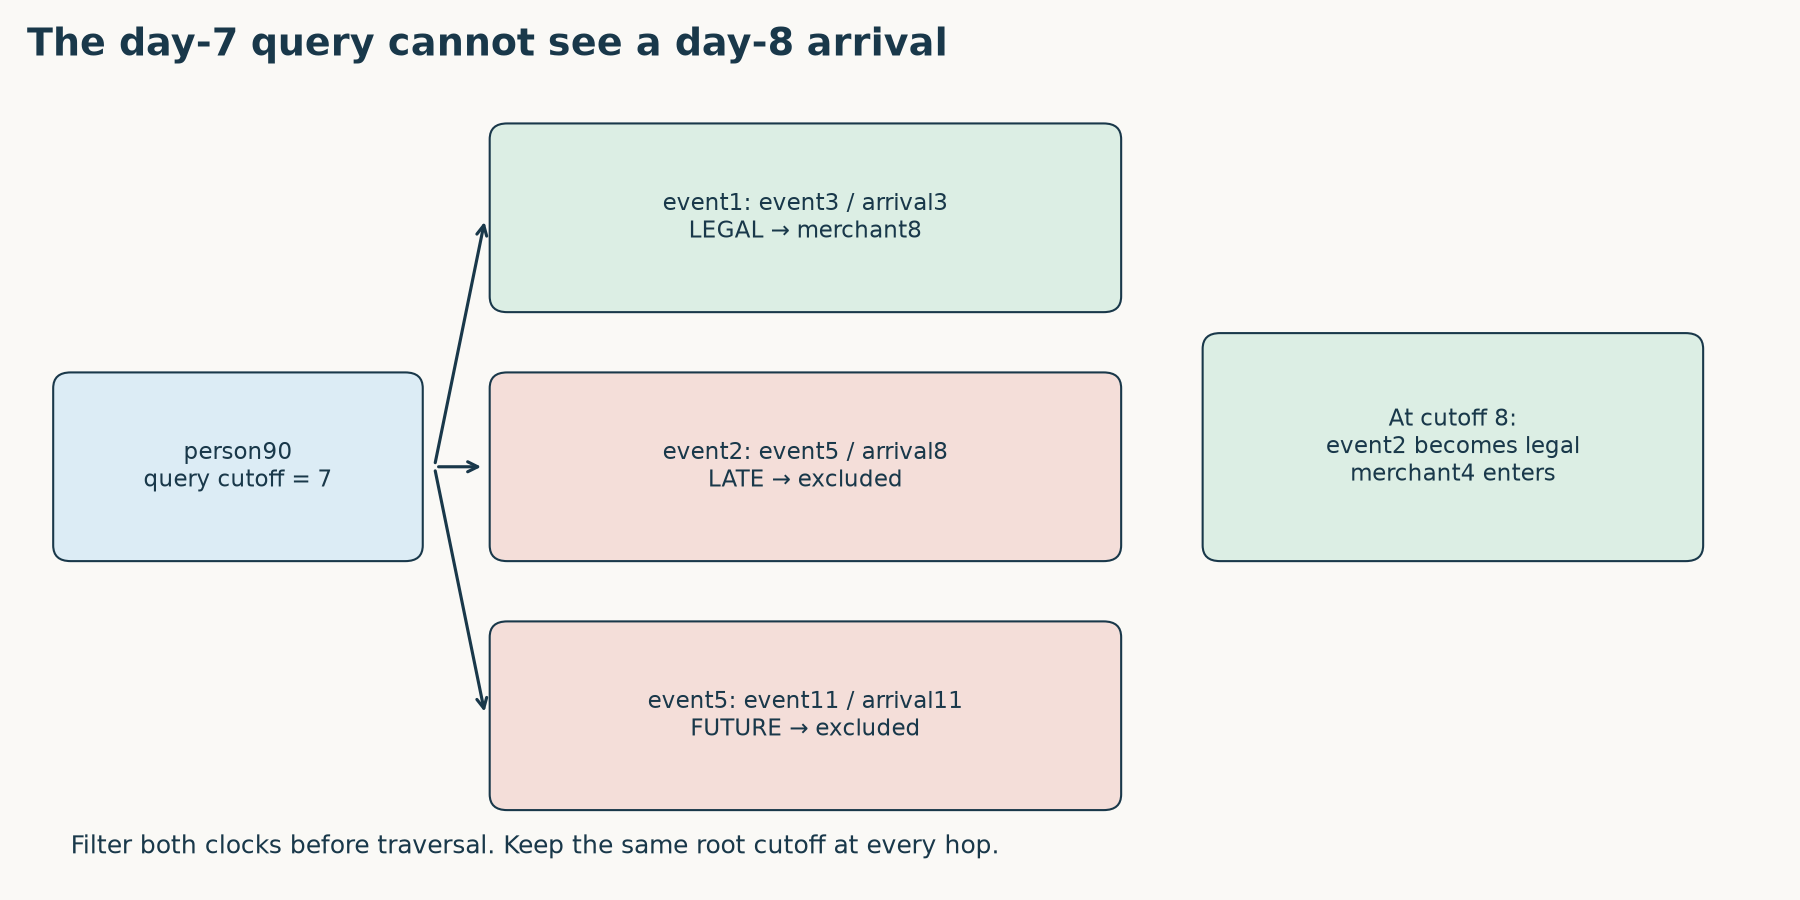<figcaption>A day-7 person90 query admits event1; late event2 enters only at day8. Both clocks stay bounded at every hop.</figcaption></figure>

Static trace: at day7, person90 sees event1. At day8, event2 arrives. Event5 first becomes visible at day11.

**TODO 2 — `visible_rows`:** implement both comparisons. The boundary CHECK distinguishes arrival7 from arrival8 for a day7 query.

The provided extractor returns a real PyG `HeteroData` object. Each query gets a separate graph, even if two queries mention the same person. `Batch.from_data_list` concatenates nodes by type and offsets edge indices; `n_id` records original row identity, while local edge indices address the concatenated tensors. [PyG batching documentation](https://pytorch-geometric.readthedocs.io/en/latest/advanced/batching.html).

**TODO 3 — `seed_positions`:** locate query roots from their Boolean masks after batching. Do not assume they are the first `B` person nodes. The CHECK inserts extra context people so that correct roots are `[2,3]`, not `[0,1]`. A separate test compares batched predictions against individual predictions: disjoint batching must not transmit information between queries.



## 4 · Follow a complete forward pass, then train

The small exam model is an original teaching model, separate from the published RelBench model. It uses the learner's graph construction, visibility, typed aggregation, seed mapping and loss in an actual training loop.

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">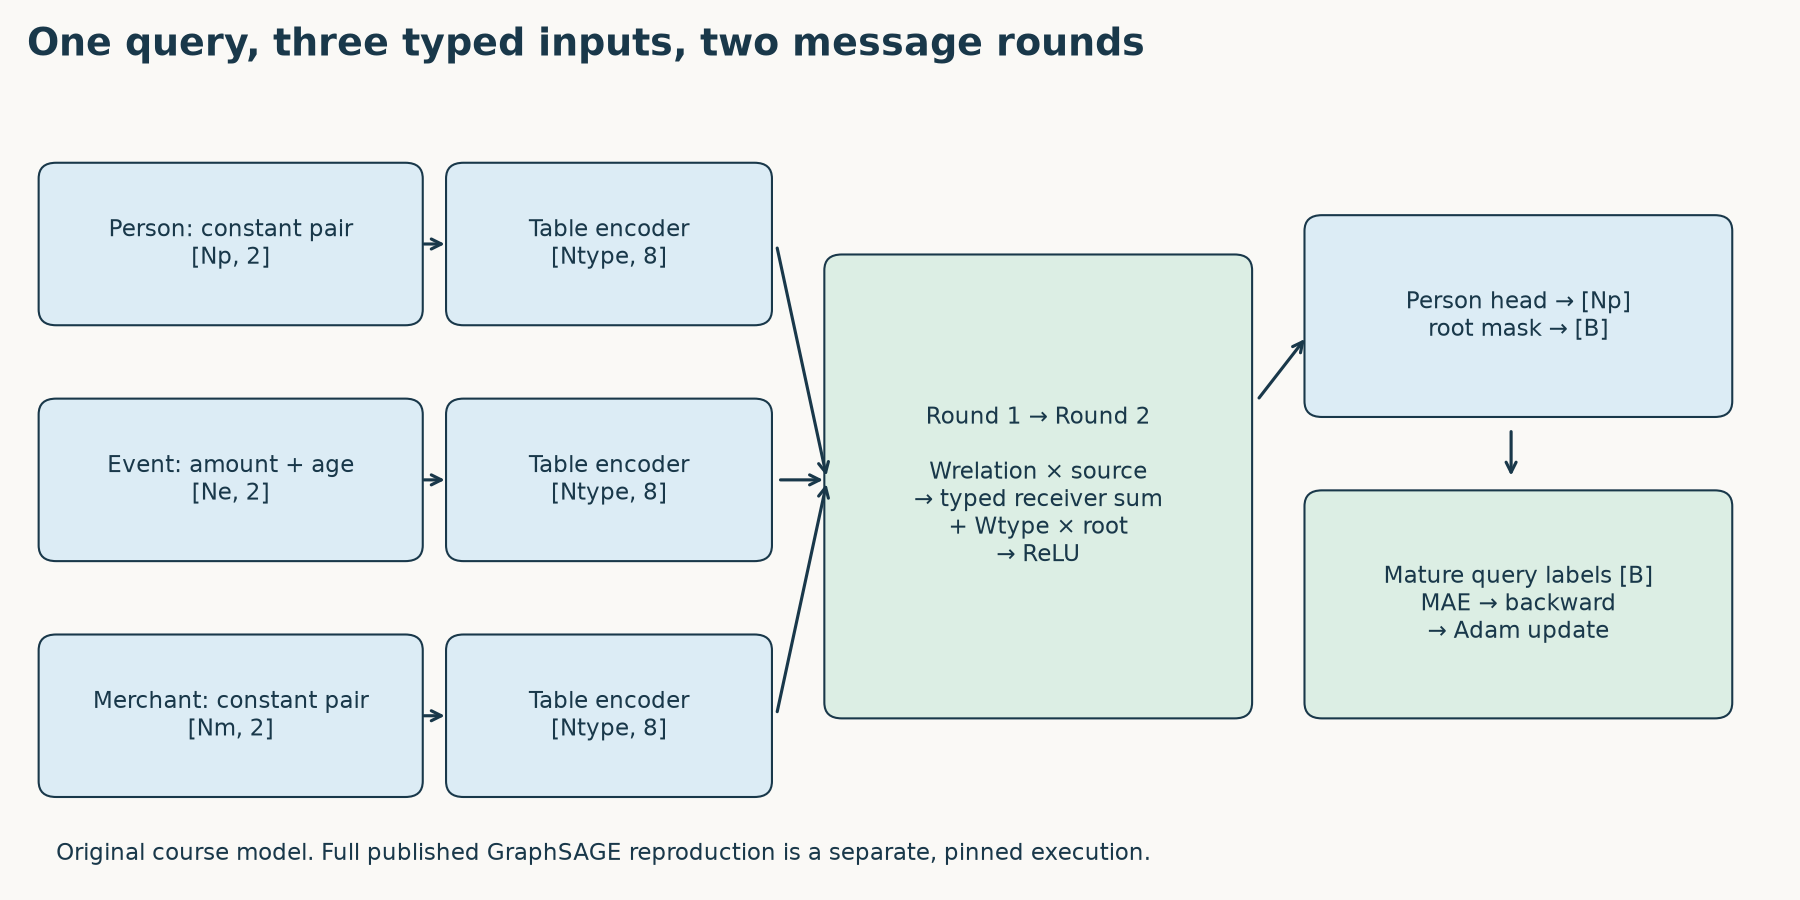<figcaption>The course model: typed two-channel inputs, table encoders, two relation-specific message rounds, query head and mature-label seed loss.</figcaption></figure>

**Diagram trace.** Compare the course predictor with the paper lane. Which input widths and encoder choices differ, and where do query labels enter? On a narrow screen, scroll the figure sideways.

Each node has two input channels. Events carry amount and age `(query_day − event_day)/10`; people and merchants use constant features in this fixture. A separate linear encoder for each table maps `[N_type,2]` to `[N_type,8]`. In each of two synchronous rounds, a relation-specific linear map transforms source states, and the receiver sums messages along that relation's edges. The model adds a type-specific root transform and applies ReLU. A scalar head reads person states; the root mask selects one prediction per query.

For relation `r: s→d`, a message is `W_r h_s`; the receiving state is `ReLU(W_d h_d + sum_r sum_neighbors W_r h_s)`. All messages in a round use the previous round's states. There are distinct parameters for event→person and person→event. That makes direction and table type part of the computation.

**TODO 5 — `typed_messages`:** accumulate into the receiving table at the receiving local index. Multiple incoming edges must sum; assignment that overwrites the previous message is incorrect. The model applies its relation-specific transforms before calling your function.

**TODO 4 — `seed_loss`:** calculate mean absolute error only at query roots, rejecting training labels unavailable by the fit cutoff. Input visibility is checked at each query's prediction time; label maturity is checked at the model's fitting time. These are different clocks. A day7 question can legitimately train a model fitted at day10 using an outcome that became available on day9.

The default notebook trains on six authored queries at days4/7, whose synthetic next-period labels are mature by day10. It runs 120 optimizer steps and predicts two day10 queries. It verifies that the training loss falls and that batching preserves predictions. There is no held-out target score or model selection in this tiny mechanism exercise; falling training loss is not evidence of generalization.

Predict the direct gradient mask before running the CHECK. Context nodes must have zero *direct supervised-output* gradient, but may receive gradients indirectly through messages. This distinction is the point of the exercise, not a reason to detach context features.



## 5 · Execute and audit the full selected experiment

The full-data track uses the pinned RelBench release's per-table PyTorch Frame encoders, relative-time encoders, two heterogeneous GraphSAGE layers and regression head. It retains the full visible implementation and trainer from Lesson 117. The small exam network above is not substituted for that model. [RelBench §3 and Appendix B](https://arxiv.org/html/2407.20060v1).

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">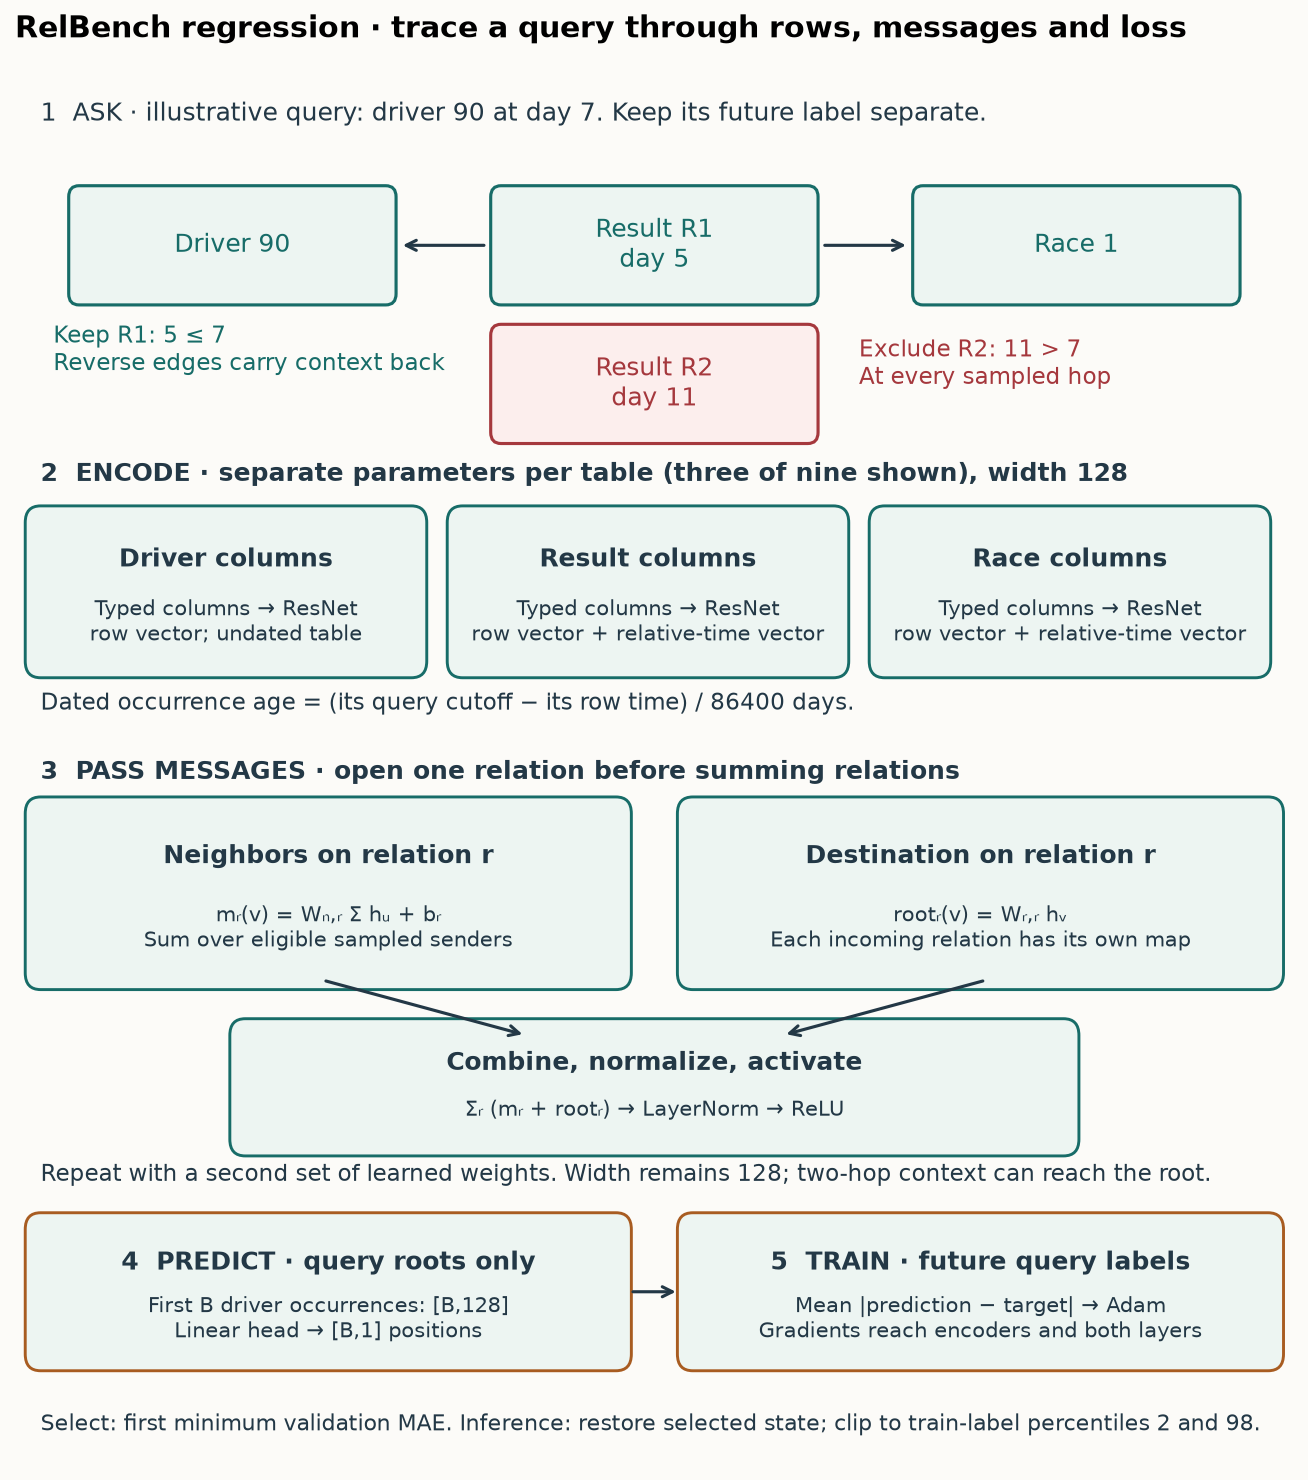<figcaption>The separate published RelBench model: table encoders, query-relative time, typed GraphSAGE and seed regression. Reused L117 architecture, executed afresh for L120.</figcaption></figure>

**Diagram trace.** Compare the course predictor with the paper lane. Which input widths and encoder choices differ, and where do query labels enter? On a narrow screen, scroll the figure sideways.

The exact target is **RelBench v1 Table 7, F1 driver-position, RDL column**. We execute five fresh seeds, all ten epochs, all 7,453 training queries per epoch, all 499 validation queries and all 760 test queries. Checkpoints are selected by validation MAE. Freeze the descriptive mean tolerance at 0.2 MAE before inspecting results; use the test set only after selection. The historical published means are 3.193 validation and 4.022 test.

**Fresh author-reference execution: COMPLETE selected released-protocol experiment.**

| Split | Mean MAE | Sample seed SD | Published mean | Verdict |
|---|---:|---:|---:|---|
| val | 3.184459 | 0.010072 | 3.193 | CLOSE |
| test | 4.071967 | 0.075394 | 4.022 | CLOSE |

| Seed | Selected epoch | Validation MAE | Test MAE |
|---|---:|---:|---:|
| 0 | 10 | 3.177127 | 4.062903 |
| 1 | 8 | 3.182222 | 4.143431 |
| 2 | 10 | 3.179105 | 4.112558 |
| 3 | 10 | 3.181749 | 3.947681 |
| 4 | 7 | 3.202094 | 4.093262 |

All **6,295** final predictions were independently scored. Maximum original-model output discrepancy: **2.86e-06**. Measured pilot plus full-fit worker resource estimate: **USD 0.0545**, excluding unitemized overhead. The aggregate plan caps reservations plus overhead reserve at USD 10. [Evidence](https://avistian.github.io/relational/labs/evidence/l120/summary.json).


The reproduction audit checks data/source hashes, every epoch, selected checkpoint hashes, query entities/timestamps/targets, independent MAE, and original-model output agreement. Sample seed standard deviation describes these five runs; it is not a confidence interval across datasets or a claim of statistical equivalence.

Read the deviation ledger before making claims: released fanout `[128,64]` differs from the paper table's128; source preprocessing fits statistics on the database censored at the test cutoff; original historical seed/environment identity is unavailable; real ingestion histories are absent. The executable course leakage checks establish the both-clock contract on controlled data, not on unavailable F1 histories. Full-paper parity remains **NOT_ESTABLISHED**.

For fresh execution, follow the exact commands and pinned runtime in the [contract](https://avistian.github.io/relational/labs/l120-reproduction.md). The notebook shows the complete model/trainer and has an OFF-by-default five-seed gate; executing the default reference notebook does not repeat the separate GPU reproduction. The runner reserves compute before dispatch and prevents duplicate launches or source changes under an existing ledger.



## 6 · Submit the exit artifacts and defend them

Use the [submission template](https://avistian.github.io/relational/labs/l120-submission.md). Submit your hand-built REG, five implemented functions, executed notebook, task report, full-run evidence or a clearly labeled audit of author evidence, leakage counterexample, and written defense. The template distinguishes your own executions from inspected reference artifacts.

Read **all of [Fey 2024](https://proceedings.mlr.press/v235/fey24a.html)**, including appendices. For each entry in the reading ledger, record a section/page, a claim in your own words, its evidence type, and one limitation. Reading the lesson or passing code tests does not complete that requirement. Fey is a position/blueprint paper; the later RelBench v1 experiment is a separate empirical target, not a reproduction of every Fey appendix result.

Score each of six domains 0–2: REG construction, temporal validity, mini-batch identity, model/training explanation, reproduction evidence, and full-paper defense. Zero means missing/incorrect; one means correct with unresolved assistance or gaps; two means independently correct with evidence. Exit requires at least 10/12, no zero, and a completed full-paper ledger. Any unresolved leakage, mislabeled evidence, or missing complete working pipeline blocks exit regardless of total.

**Current learner status: PENDING_WRITTEN_DEFENSE.** The executed teacher solution does not change that status. Explain one failure your tests catch and one they cannot establish. Then predict what changes when event2 arrives one day earlier, the hop count increases, or query roots are permuted.

Ask the agent follow-up questions whenever a step is unclear; name the node, tensor or cutoff where the trace stops making sense. In 1, 7 and 30 days, redraw the query graph and reconstruct the loss mask without notes. Lesson 121 begins Year 4's history of relational ML after this exit is demonstrated.

<!-- sequence-next:start -->
**Carry this forward.** Use the historical map to understand why the Year 4 design choices exist. [Continue to Lesson 121](https://avistian.github.io/relational/lessons/0121-history-relational-ml.html).
<!-- sequence-next:end -->


### Imports and immutable course fixture (PROVIDED)

In [2]:
import json
import torch
from torch_geometric.data import HeteroData, Batch
PERSON_KEYS=[90,10,70]
EVENT_PERSON=[10,90,90,10,70,90]
EVENT_MERCHANT=[8,8,4,4,8,4]
EVENT_TIME=[2,3,5,9,4,11]
EVENT_AVAILABLE=[2,3,8,9,4,11]
AMOUNTS=[1.,2.,4.,8.,3.,16.]
MERCHANT_KEYS=[8,4]

/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task 1: relational identities

Implement this function, then run its unchanged CHECK. The complete training pipeline calls your function.

In [3]:
def key_edges(primary_keys, foreign_keys):
    lookup={key:i for i,key in enumerate(primary_keys)}
    if len(lookup)!=len(primary_keys):raise ValueError('Duplicate primary key')
    pairs=[]
    for row,key in enumerate(foreign_keys):
        if key is None:continue
        if key not in lookup:raise ValueError('Dangling foreign key')
        pairs.append((row,lookup[key]))
    return torch.tensor(pairs,dtype=torch.long).reshape(-1,2).t().contiguous()

In [4]:
def check_keys(fn):
    assert fn([90,10],[10,None,90]).tolist()==[[0,2],[1,0]], 'Keys are not row offsets'
    for pk,fk in [([1,1],[1]),([1],[2])]:
        try:fn(pk,fk)
        except ValueError:pass
        else:raise AssertionError('Reject duplicate primary or dangling foreign keys')
check_keys(key_edges)
print("PASS: key_edges")

PASS: key_edges


### Task 2: point-in-time visibility

Implement this function, then run its unchanged CHECK. The complete training pipeline calls your function.

In [5]:
def visible_rows(event_time, available_time, cutoff):
    return (torch.as_tensor(event_time)<=cutoff)&(torch.as_tensor(available_time)<=cutoff)

In [6]:
def check_visibility(fn):
    assert fn([2,5,9],[3,8,9],7).tolist()==[True,False,False], 'Both clocks must be legal'
    assert fn([7,7],[7,8],7).tolist()==[True,False], 'Boundary is inclusive'
check_visibility(visible_rows)
print("PASS: visible_rows")

PASS: visible_rows


### Query-specific temporal graph extraction (PROVIDED)

In [7]:
def query_graph(person_key, cutoff, hops=2):
    person=PERSON_KEYS.index(person_key)
    ep=key_edges(PERSON_KEYS,EVENT_PERSON);em=key_edges(MERCHANT_KEYS,EVENT_MERCHANT)
    legal=visible_rows(EVENT_TIME,EVENT_AVAILABLE,cutoff)
    full={('event','owner','person'):ep[:,legal],('event','shop','merchant'):em[:,legal]}
    full.update({(dst,'rev_'+rel,src):edges.flip(0) for (src,rel,dst),edges in list(full.items())})
    # The root cutoff was applied before traversal and never becomes a neighbor time.
    reached={('person',person)};frontier=set(reached)
    for _ in range(hops):
        found={(dst,int(b)) for (src,rel,dst),edges in full.items() for a,b in edges.t().tolist() if (src,int(a)) in frontier}
        frontier=found-reached;reached|=found
    ids={kind:sorted(i for k,i in reached if k==kind) for kind in ['person','event','merchant']}
    graph=HeteroData()
    features={'person':torch.tensor([[1.,0.]]*3),'merchant':torch.tensor([[1.,0.]]*2),
              'event':torch.tensor([[a,(cutoff-t)/10.] for a,t in zip(AMOUNTS,EVENT_TIME)])}
    maps={k:{global_id:local for local,global_id in enumerate(v)} for k,v in ids.items()}
    for kind,index in ids.items():
        graph[kind].x=features[kind][index];graph[kind].n_id=torch.tensor(index,dtype=torch.long)
    graph['person'].root_mask=torch.tensor([i==person for i in ids['person']],dtype=torch.bool)
    for (src,rel,dst),edges in full.items():
        pairs=[(maps[src][a],maps[dst][b]) for a,b in edges.t().tolist() if a in maps[src] and b in maps[dst]]
        graph[src,rel,dst].edge_index=torch.tensor(pairs,dtype=torch.long).reshape(-1,2).t().contiguous()
    graph.query_key=torch.tensor([[person_key,cutoff]])
    return graph

### Task 3: mini-batch seed identity

Implement this function, then run its unchanged CHECK. The complete training pipeline calls your function.

In [8]:
def seed_positions(batch):
    return batch['person'].root_mask.nonzero(as_tuple=False).flatten()

In [9]:
def check_roots(fn):
    from torch_geometric.data import HeteroData, Batch
    graphs=[]
    for n,r in [(3,2),(2,0)]:
        g=HeteroData();g['person'].x=torch.zeros(n,1);g['person'].root_mask=torch.arange(n)==r;graphs.append(g)
    b=Batch.from_data_list(graphs)
    assert fn(b).tolist()==[2,3], 'Query seeds are not necessarily a global prefix'
check_roots(seed_positions)
print("PASS: seed_positions")

PASS: seed_positions


### Task 4: mature seed-only supervision

Implement this function, then run its unchanged CHECK. The complete training pipeline calls your function.

In [10]:
def seed_loss(predictions, roots, targets, label_available, fit_cutoff):
    if bool((label_available>fit_cutoff).any()):raise ValueError('Immature training label')
    if len(roots)!=len(targets):raise ValueError('Query/target count mismatch')
    return (predictions[roots]-targets).abs().mean()

In [11]:
def check_loss(fn):
    p=torch.tensor([9.,2.,8.,4.],requires_grad=True)
    loss=fn(p,torch.tensor([1,3]),torch.tensor([1.,6.]),torch.tensor([4,7]),7)
    assert loss.item()==1.5;loss.backward()
    assert p.grad.tolist()==[0.,.5,0.,-.5], 'Context rows receive no direct supervised gradient'
    try:fn(p,torch.tensor([1]),torch.tensor([1.]),torch.tensor([8]),7)
    except ValueError:pass
    else:raise AssertionError('An immature training label leaked')
check_loss(seed_loss)
print("PASS: seed_loss")

PASS: seed_loss


### Task 5: typed receiver aggregation

Implement this function, then run its unchanged CHECK. The complete training pipeline calls your function.

In [12]:
def typed_messages(x_dict, edge_dict):
    out={kind:torch.zeros_like(x) for kind,x in x_dict.items()}
    for (src,relation,dst),edge in edge_dict.items():
        out[dst].index_add_(0,edge[1],x_dict[src][edge[0]])
    return out

In [13]:
def check_messages(fn):
    x={'person':torch.tensor([[1.],[2.]]),'event':torch.tensor([[3.],[5.]])}
    edges={('event','to','person'):torch.tensor([[0,1],[0,0]]),('person','rev','event'):torch.tensor([[0,0],[0,1]])}
    out=fn(x,edges)
    assert out['person'].tolist()==[[8.],[0.]] and out['event'].tolist()==[[1.],[1.]], 'Aggregate into typed receivers'
check_messages(typed_messages)
print("PASS: typed_messages")

PASS: typed_messages


### Two-layer heterogeneous temporal regressor (PROVIDED)

In [14]:
class ExamGNN(torch.nn.Module):
    def __init__(self,channels=8):
        super().__init__();self.kinds=['person','event','merchant']
        self.relations=[('event','owner','person'),('event','shop','merchant'),('person','rev_owner','event'),('merchant','rev_shop','event')]
        self.encoders=torch.nn.ModuleDict({k:torch.nn.Linear(2,channels) for k in self.kinds})
        self.root=torch.nn.ModuleList([torch.nn.ModuleDict({k:torch.nn.Linear(channels,channels) for k in self.kinds}) for _ in range(2)])
        self.message=torch.nn.ModuleList([torch.nn.ModuleDict({r:torch.nn.Linear(channels,channels,bias=False) for s,r,d in self.relations}) for _ in range(2)])
        self.head=torch.nn.Linear(channels,1)
    def forward(self,batch):
        x={k:self.encoders[k](batch[k].x) for k in self.kinds}
        for depth in range(2):
            sums={k:torch.zeros_like(v) for k,v in x.items()}
            for src,rel,dst in self.relations:
                transformed={k:v for k,v in x.items()};transformed[src]=self.message[depth][rel](x[src])
                out=typed_messages(transformed,{(src,rel,dst):batch[src,rel,dst].edge_index})
                sums[dst]=sums[dst]+out[dst]
            x={k:torch.relu(self.root[depth][k](x[k])+sums[k]) for k in self.kinds}
        return self.head(x['person']).flatten()

### RUN: complete small training and inference pipeline (PROVIDED)

In [15]:
def course_run():
    torch.set_num_threads(1);torch.manual_seed(120)
    # Authored next-period targets. These are not measured customer outcomes.
    train_queries=[(90,4),(10,4),(70,4),(90,7),(10,7),(70,7)]
    targets=torch.tensor([3.,2.,4.,3.,2.,4.]);mature=torch.tensor([6,6,6,9,9,9])
    train=Batch.from_data_list([query_graph(*q) for q in train_queries]);roots=seed_positions(train)
    model=ExamGNN();optimizer=torch.optim.Adam(model.parameters(),lr=.01);trace=[]
    for epoch in range(120):
        model.train();optimizer.zero_grad();pred=model(train)
        loss=seed_loss(pred,roots,targets,mature,10);loss.backward();optimizer.step();trace.append(float(loss.detach()))
    model.eval()
    with torch.no_grad():
        test=Batch.from_data_list([query_graph(90,10),query_graph(10,10)])
        prediction=model(test)[seed_positions(test)].tolist()
        # Disjoint batching must preserve each query's individual prediction.
        separate=[float(model(query_graph(k,t))[seed_positions(query_graph(k,t))][0]) for k,t in [(90,10),(10,10)]]
    torch.testing.assert_close(torch.tensor(prediction),torch.tensor(separate),atol=1e-5,rtol=1e-5)
    assert trace[-1]<trace[0]*.5, 'Reference training did not learn the course fixture'
    return dict(status='PASS',scope='COURSE_ONLY',initial_mae=trace[0],final_mae=trace[-1],epochs=120,
                test_queries=[[90,10],[10,10]],test_predictions=prediction,batch_vs_single='MATCH',
                split='train query times 4/7 with labels mature by fit10; inference time10',
                learner_status='PENDING_WRITTEN_DEFENSE')

## RUN · your complete small PyG pipeline

Predict the legal event IDs and direct loss mask before execution. The report proves reference execution, not exam mastery.

In [16]:
report=course_run()
from pathlib import Path
Path('l120-task-report.json').write_text(json.dumps(report,indent=2))
print(json.dumps(report,indent=2))

{
  "status": "PASS",
  "scope": "COURSE_ONLY",
  "initial_mae": 3.178100824356079,
  "final_mae": 0.04033859446644783,
  "epochs": 120,
  "test_queries": [
    [
      90,
      10
    ],
    [
      10,
      10
    ]
  ],
  "test_predictions": [
    7.90453577041626,
    10.874335289001465
  ],
  "batch_vs_single": "MATCH",
  "split": "train query times 4/7 with labels mature by fit10; inference time10",
  "learner_status": "PENDING_WRITTEN_DEFENSE"
}


## Audit the real author runs

The embedded predictions are from five fresh full-data fits. They do not replace your own training evidence.

In [17]:
# PROVIDED: independently rescore all fresh author-reference queries.
import numpy as np,io,base64,hashlib
payload = {'0': {'base64': 'UEsDBC0AAAAIAAAAIQC22H1s//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAQAcAAAAAAACdlOdbFGYWxQFp0h1mGBiGYWjCBBBFShSE9weIioCgiPrIgIIgsooIigMRJPaOWXWt0SwqsSAhkrBGWY1iiSXAYtnHaCJ2BZNFozTbzv4Le7/d8+U8595zzpbEyQlJ0wwNig0+856VXZRV6D1S7R2eE+Ttp/bOmV+4sHBmfsb8wlnZ/8NjZ84tytbjRbkzC7L1u0/QiBF+Gj91mfr/Hovc8z3iSlI0hzM6RPyCMfg8U/NjnzcBY9XMkbwX3Rd8STP1Yf+JGTy5GM7RkVpU2cHkZXwQInwr89uHEvVsFpIJ1sxrCeGNqxmX4vxxMounsk3HdsVkJB8NSCk24aDag7FtGmK2jGLVLWdqW5OYEmtP7qcyvjyeit+4UrytFIz62ZC9+S7scNGw6YqU3gg5A2tKsPHzw/ToJ6xuk/LjFWOUgRIaNoUR7ZBBZaSU4F5vKm6oCa00YvdyHdkLTfnaOgu7zRNRGiiZvUfL0KGOVH9RRL2lI0tL3fnzTq+o/daKnBI37Px1TG7qEUe6W8V668F0e89kzyIjUuzNSB8ZSk2ODfdOGjLnojsFESoqBk6iIyGUAVkfxbtbAdwqKMF3r5qNRpks3a/C6b4rc8qTOJT1Ruy2l7Ou3I1Hh1U0x7ux61Asf/vMi3fLR5P69J4Y7aPDcuUL4erpjzf9YuHkeIJmOJK7xJ68k9ZU50qJ1ZijXaLlYJAFfv8xINzTC+PbLowplPEkUsWm7FnYXUjG4m4heVNUfChfxMsvpBgaR/PR9K0Y9TiU3iAnDC8+EhJtBjmLFOy4HoP1r33iWp2G/R9l1JSF4LXfmo0rNCyIeS9sCszYm2zAV9f8GNppz+E1U9me0CnyahyYeGweinI5IbVODKt/JY43JWDTaIHy2GAehHji2WpJm1GPWL7OhfDueE5vCKXRR8nmZ4mY+47CKkTKjnOJhD18IRQF6dR+/inSqRoSNiahOOWFlf1wEg3ziDUMpuuBBw5dSu5EGRIuTHhyRkJpdDheTGFeZiC5LQr+kMuYGivjw7dLkfZHEtfgzP3b+ZQGvxVpkR68OK3mp2cRZMxvEZFb0rDStYgVCneuultisrJXpPxpTt0pT7bGenD3loTA8UZcTZhOTpwJjY4GLKh35uhtFb5vs6gLzcbWV0dJWodQxJcSY+OAbIeOhhANsc+LWHDqnbC4qmKnnmOMLgOHtXJSHt4SgaZyvjsoY1W1FvcJJSyMGE5yQzxl2X780jEIGozo79Owr9+NX+aZ09o/k8bILLJOuBIb5MqwQDWyplLqu/tE3ms1VsOmk9qpJjrWjQd/HcPKan9EkzWla9QkbrPF7nMFX8b0CYtHs6jTKDkW1it6r1px56mUsoD3ov2CH/MrDdkksab2vJKecxKubAkipG8Ayt8q6PXPoLpxNkZGkyDwtZAceC5uRKSzd72Mc3ot4+4ncCnYkivaP4Tjsm7RKFES8UqLQ1uPCF4wm5cH+kTDACWrCweR0ubGuqlOPNb79fKFe+Lcxkxy3XxoblVw21HByV57LqTo8HligW1VHl2rCvnhHwq6fh+I57F46lqcaX+tIqg0lfg9Orb4qthW/kSsiZ5LTc07ke8iyHRy59p2FeUrXQiw6RbKYA1OyUa8WmbOP73SKf7XCGK/jmN0tCOhHS9F8zoJ2gQpjp46/R+smBb1Xljb+9OYNJy/XzFjaICO3+ptOd7phtFiW1Y8zGD33SS0sc9FwosXwmOkjLH6bN88JWPpCG8mXVQzPGAm7c5+/OrcKc4VCQraboq9FTbkDPYhbFufOKjv1K3rkzmTJqdirQFDihOYPciL1hAdHW+ssVufzy5De8LaM/h3tgyHSDeOFLpgc0DL3XYnNJ4vxKnkHpG2aCDHq6Cp/q1YfvG6OPYshhu2rsSdcOSrxWquyeUsuy7hpo0nphEKyuqdCPH8hGzbfhE12wXdEnduV2jRng8mLN+EP13tqJC7ELMpE+cTHeJBu5JEt4ksfdolNqyTcr7YnpSudAJXG5NxPpWwQx5Unrfkgb4rLHaqCcnVe9bMiVXSUnbqO3Tx5W5R/Y2M5Iq3QnPano5aZ3a1yDmyL5KGynFsElHsyBuOnbEZx76bwcXf7TCeP4Pda1WclU0gsXU8VT8oeFVSws/q56LnoZyCv6ixmG5F4nYvoirHcOnIIzExR0Ht42Sy9Le5f/ap6DPvFyEmmXivcuTyinHsabLV5zWJsrh3omNHOibNgSgmTmCIpQ+ZJ0fx/U0D6gv7xY25tuzTa6vbOpwNayS06n27JG4ppe5donRtMm8md4qTVR6cmy6nOVtCyUYF30xSUz73rYhyK+GGMorvh5hgWuOPZ/pYQjJdqWrqE826PuEz2oFLWzqF1+5UvB6+FuWuYzlRKyPubACXhkr4KV/FI+l4Cs2d2V8Gq6apGVJpQ8/mDFLeFXNmshHTekYxoeKNuHsvhw+dCkanlVAllxJ2pIjXxRL+C1BLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQC0JOhu//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAIEIAAAAAAAAnVZ7VFNHHr4J2CIqSCJECcm9CYSgoksXUcRS74fyTIJSQwiCIhXQ7sFHhVWwqNQHgtW1hbjKatfl4WNBOVL01K7YntO6itVddYuPVbSKa2UVARGttSXZO3NNav/dnDPnzp2Z+5vv+37f/CZVyamm2ekSZiXzvj4nt2DhCn0Up38zb5I+lNPnLVtRuCJ7adayFTm5ZDwuO78gVxgvWJy9PFd4D5kyOSx0bCi3hvu/f55Wvx0YM8QNKzuKsA9F0DytwBZpMU7+yOGccjsW9mzAjNdLcPt7OfrHrcYipoS27XFrsfbODjrvaSnBggcSGoOsfXWurpdB5UUVQoaGYPANBhOuFSEivhRHzvnArcVI94rY5IMDCzai4QMOXbZi2g/P7OVLNXp0fqJCemIg/e56sDce18TQ/v1sHsM7vFAz7xmfI7Wg7q4Sj3LkqD8wE501yS4eBPPBE3IQnn+zhCDLEELxE8wE739HSilO0sg4wU++aS+U0zVkbMcFBhNPBqI/LACjh1iRYHBD++mFCMszYE0zi84nPph0J4nuN+p3ITjTwCLs3iB/cZI/tIG5+K65mO71lVHUiLzX1uViuhdDuRLOCx4p0fQwFYtPKjC7OZHmgqwNTXKn2Akm/y/kFI+7RQv1zrm0/568BB4TGRyrtmHMlmA06sT+lEtVFM94mw4jd3PwOJiGzeMc/JKngci7GYJ+A0u/X/2+CXsVPmIehLx4/MWH6uvMg7dditfyF6DmVgLu+jj4/j/rYQULS9A0aMK9YHzPCEOUN7bkJaPguwAXH3tRKu6F+6FqcywW7p2F3hGif5x58bwrdXEkPrvE2HmCm/SvTJXi6802PDdasfo1DZpjLPCI0WKLPhgXLuswtMrBkxiHK6y4/bUaPT+Oxe/vsdhzVkK9V7R5Lc3n+QopEqpzXFwuDuMox/8ckGHV8h/4ihux4MP8UF/vhq2cDp8tUoL7eyqe1fhjrnImmAhfFIxIoZ6I+VTUlejt5HC5tIy+Ex2Pvj4X5VkaePRyKK/mUHxM1P8GK6H94x8Firl7YaScv2yS4nyYEldfJKF2QEnxkRad28Pvyg+mHOxt7rB9nIT6DAVqF/nBut4d/3KYYE5n0dTxkM/UpKBpqwH/2JsBvxQtxUl0u/dXCdg7EtonehKcTszvlnD0Wd4zSPUm2EiLn6JGmtaMzkfifG6ZhmIgehItdy0IxAW1BJVcLPXHGwUynG5Z7cLt1Jg8Tase8YeXcSj9jT9uzeZonJprw7EpxIiBjh7+TlsS1aJcvwZDa20o6/rFC8465HtVgoZoDcUSv5jF7UXBtL/0hpzitSaw9N3jzFyEPlUhu93BPzEbEKuR0hi598R9nfic2Mi+w7NUKPw5CM/7gzB/DIfMDhYjhrEYv94En+YhiIQCH+l9EV43A6q6xQiONiGwTE+/Pb9d9HFcKovqFrHvzDVprX0B2Bmro2MDjQ5+3CkLJl9XwTAknuo2s0cGZRVDY72q28WLLHJqe3mC+Xi4Dsc3zsScq/44ul0Fj+tFuLmtm8/+tJsvX6elnov4WPQjyS95elXZeWddI0+S+3GxEmyzVlFfkEbmSC5JbSZ5da4Pq4+j2J51yyCrMQoeFuuUgnHwPofsvHeKDf2zrGja0M3nb1DD0KBHpFKNwMcjUZov1r182xxUsok4fE6Cu0t+4Ksjn/MkZsYxHo6FXi6uS+cEoPWxEhXNo4A/GDC9T/Qpwel7koXpGQf+nUyKbZSfFj+Z0n/lX8KXcHHeO6SRd7J+p3BGndyc95Y2Jwn7b4qeOPW2nMZY93QG5Vv5jQwfTrCi6y0Vyga0kP82BJUKNVIuZCDnlOC5klQXblI3roX5IHKvEePXeFFvOev6vis5SG9hYM9Jw5uz07DC4IuExESal8aHDMXxwnM+9m/nYH6Lg+WsjPrmfIoGXRVSl+cHqhmqA9FD+ly8kwm/T+4yeOIneo3EIuN9690w4Y/Mr84oPVPHxiI0WI2206Px4Lg/0hQml/9P2zJQ7J0BWyeLxkE19kT08ITbfmEuIUND+fiVSlAoxF8e/g4+UCqgHjOa7tHo2cMTHx6NSEZY8zzs2qmh/K7cd/CFL/E/DnDDqX49VqaIWElr1csR87IuTdOIfuxvZ1w5p9+elFCeZP3tcDkWCzx+XqJ18SL7t02XoVzI3f47mfhnnOCJ8Wmw+wn36xgjnTd3cDSn7WHe2H0oBsuP9vHknKwcYF17rY+WYni8Hj5rpXBi1rtrcLDDQs8r4bNvi4P3dRPvoshmM5haDqZGHdJbOdgr1Wg1p1McFcvk6O020jjbrkso5htCDSJnxanpmm8DMFnwTf5wGdZXxlJ9yfoTX81HSacE/rdMyN/jhQcbzQg+1Mc7cfp3S+kZJ3o0dMrwxTc6iq08y853CXfgNaGGd3yeAYlcg1YFh6B2C8x5gzzhsLw5COk2Oz/xQ/FMt06RUQwvfhL1e9Uvl+aGIDmCBcFM8O5/6XXHnlT8u5SB9ogE5rMJ8HSfR7+1WQxIiRxJ42474Y2+VcL/nFM6wK6C7YIObUEqXJ6iwrWMRTiSLsfYWbH49okCk3bHI6ZuFnIfyKHQCv/5hLpP9Gqy6Glu+MdiLbvRNsg7eW81yShGote73u70KfzRo3NRgTI0CDWUxCDv92fLMMJs58OF/3ZdU1nKkZmqwRnhfvrsYAbSkllcPZHmysufvvRHXnIiCkfpYOSi6HrSovKVOK3r40NbUmnNJY1rNOJ4vZ5iJjWoXahFRAuCkzzbX9Ym4yYLuAkaysfdS+LytjzazeW/4mjRJ593i+djV5tYByYPE/3ozAupYWVvM/Db6UbHQzNVUPumIW6dnO5JYkyrtiIrX43vmV6+5SqHqLUKbD47A1uXjoYu1B2B45/xthEB+B9QSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhALbYfWxABwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAX4HAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAQgMAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAQ0PAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAtCToboEIAABgDAAADQAAAAAAAAAAAAAAgAHoEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAagaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAEDIQAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABGSUAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAA7CgAAAAA', 'sha256': 'f6780b9bc268071ece6fceb88a646a8300a29cf17dda206812c7524875cf9f52'}, '1': {'base64': 'UEsDBC0AAAAIAAAAIQBRGDiE//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAANgcAAAAAAACdlelbFOYVxYdlQPZhFvZ9X2VxQCQu709kUVECAiKPYFlFQEFEQcVGGHArWqvWYFwqWI0lxKq11mpLjdA80SLxidVgpGpdAqMSUANBROjkX+j9du+nc88599z9i9MWfbhMT7JBstk3v2BdXoVvtJvvzEK1b5Cbb2FZRWVFzpoVZRX5BT/P43JK1xXo5uuKcsoLdL2fesaMIP8gty1u/3eZHiufFEVGady7/0b0fBrHsmFP7GsCqYxxYaaDhOodgTzuCGAivgity0Iy2gsoXRzDwCt9VsbWc9FqNkMmdahuy7mVEsnZuXr0NoZw/vtFHHqn4Xh5Bn519gReM6X4pAetZ71ou7KMSbkz1weyGfyrBfozVHySVIJqXMPezgD8aw2wCXYixj4YbxM5PbG2tI5ouJoylW3/mE+RrxWFe0z56JiSjc0ChUkuD761IvyNO0WJPoQefCMWDmsIrvagbfpGAurX06H2ojWlmNReK357WkPPHTnR2U60XHgvvjOYwsQ1d94NaCieZUS3dZ94fcqHw9cKiI9TkJw5ISRNkXgUKZj8Qkr7Qme0Fi4UFubyVYkg4ISKWgM1/9XhnxXjwB9aNjEl0ItKqTdPL2ZhZDUkgifkHCp2oynQnoxoHca8WH7v6os6O5XLE/3i74MaJOeHxPGmOazYK2XraDouxXZkJVqSbTIFZaCC5mZD2tbm4jCgz7NwBU/3uzDvuTt7yiyZN82Vv2zagsPj5czy305QvxcLezRczpahNptP7jFDql4lYLnOllSPQaH/YQkHcp2RZGRze4+EKNsQLlXZ4LxjBmd7rQlcO4PnShmqYQnqZilPs8LRC7PA+sRamk68EBtmKlm8u5ZpgUr6NXKudr8TZ98n0x1sStOQLwvG/KncYEz2vbfCaqEbspxEvo2cxfIae/ZcSEI+NQblFAuaQgsQFe9EyMk8vumP50vhifBPovOqIynJs+l8Xc3TRVHcfeFMepcrIymGzO6YFKVfW9G8PZ4fjhYS0zCd/ioX3lbKSF2j4OFHOxlhDlPveWLdsovTmYZU6/RPGnTkoz9mcCzygZBH1BC89aH490Z3dlwwYLrchPFf6RPZG0b17+wIPSljqecUPo1OpsbGlYQLL4Wm0ZWhX7szs3oLBwprOaXT7PbHz8SJ9xq69ssw0fm9syuEQvVGKjLHRWeuiw7/Y1G6bzNNCmuig4ZEmreCrDEHpAvzOfKjBq83fhRrY4kfCqUg05wNK8eE1tITO39fXkZZcH51DU9u1nBwiSc+1t4kzvFhrVE9JxV6jKwP48GjciJvudDQ6cPxhHiOiHDSXppgWerIThMzwn3sOftYysPCTXR9ISctdApz1VKSr8tIGTPHqTiYlTWGGLXJSf9czvejHnQ0TCPx6LB4F1FPZVYVWV/WERWxnJutL0WInVb4TFawIEPGqJ+cPtMUbDQmlF4aFSmy96JX5cjX0jV01RuS61zD6VApM486Y7zLnNCt7uSV2ZOWYs3l56NidHsRb5L82bTNhsOuKi5vsKCjT4NTgyH/2VZF+9N6yiUmfHXYDTPtbloMnImY702jKgeljmuXPwfi2/xIyLvr6HphwPFNs9ms8093mRNu/jJeGUsI0voRdUef6UeMCNQroHNVAls1OewLteTG9Umdj1V0hJlzUqsh0U7OTa0+498Foz+qJtppUih0mbDKzoWO93Ic4h3onVvDmczlBO3rEw8SnorgJCu29cgJ8JOx38iXv1U6MxFTxYXPZ1HUMyhqgpJQH3oozg2b0Ws8lbcRErpDvPHfnIYok7G2yoAbf4qjq90V434NbWeMUIbuxF9pyb6xAqrN3fimxJpXJ125pCpB+ZM7+2ufiJkPJsQBSxMc/hWDT5iUqRceicTMNIbP2XMxR4XTBx7snHSg6b4llVov5jWraJvtSO6tAMobLTib6U+cvi1hXcXEtkbh5jQu3FfZkxrnSnPVFpy0z8Rng95MJOXQMaYVu8JkiIOefOBVxqmdUrInV2GQHKzLKGN+eT+Ax8ed2HvOnZ2pNrS90nCm5JnI7THiybCSut1mpNvICJ9jy0WVC3e3ZbB/Txzb/jmP2LfhKPreCbliNQEvHPnk2GZq3D1pUabhtyCDeCsflozpcnnVI9GYLCM92RW3H425siKIl6eX4Vw3JOJeW5FxuIDWaHPaGl6JDQkSnK6tpz3MCXlcESObTBnPW8IPjXrsqM0j3GIOVwwXcaTFnV/8Rk3hNENUAxakGtli6DMqlnZHsCTLh0PXLZl0r2frhFbcsUjn4MATMX4nhP7rSlpWWnBDKIm7rdt5riHnRnUYrRO4Gyll4/lwOh3mk2XswY6aSdEXPinKJRaMvPxJ5B5aTaqtPvnH8tnXbsnyvHBOV0pR3/SgpTSO6I8dyL+bScpSR8bKlPjklFAW0cCRtGEdn1HYHBwQZrq7GPnMGw/djxNGchR29QSlWPI/UEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAP4G/9D//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAaggAAAAAAACdVntUU0ceBkliLhUfValCkhtucBGW5eCDYLHV+VyK6FIBsYoIBtBE5NSaAG1VFHnE+kCx0qOo64O2lAoeEW2hCL6WdVn3RanbdV2r1LdIq1IFH0kke2duk7L/7j1nzjzu3Jnv+/2++eZ+NOetNxMWenq855EftNSYuyQnKEob9JppclCoNsi0MicvJ+Mdw8qcpUY6HpPxdq5RHM/NyjAbxf74SH14aHCodp32/368E7+3YlXmYAT1l2DTjyW4WWrFo74SbNmmwfuxViyJt6JIacVCBYcd4pxpT6Uij7SibtkG9r7f04prnnK2Bp078N0yg53EzlFj7yIBOSedxPd+CXTZVkxu5yCbkcT2ysrjUOFlBUarcEpcm7aFQffInX/qsNbMo/KpFvS7+CIlrD/Es/YOUzyU3ysRZrSTl61mXLyuQpNpKJpa9HgzVu/mQTFfPcqB8gw9pEXxdp7hp5gp3tAIBcNJCx2n+Ok333zGsTl0rLvGTlJaeeRVCYg+sQSpzXIkzchHf5UBHUNU6MnlkP36XLbf/pBAdK3X4O+tdjJ7zFhMOJWPzY9L2F7KKhmraf/LsWsx9WMF40o5e5/xh6PQjPSZI5B+IILlgs49Xqxg2Cmm5ZkcwxPnE4iUGiNr94nj66b1k+3/suJJCw+ZysnaE3ZI/C+t5+H5RwGkwYjOIgcJ69Tg9vRArPhYy76fv3oudsRxbC7LSzbH4uvKQ2aZDGMS89H6QRrGf2onpDAQhQ818P0iAuVrONT2JqH+d95Q585F2wHezacg2YxHj0fgQkMEsta/iglDvBkHV17qh8vdHKnO5vXbGW7a3rXdQfynWeEXZ8TpnTp4jzbCNjEQL4k5KMrlMavUTugatnIjJp8W8IcWHVI/CUB7p41Q7VWL+9N8KnfL0HMx381lU56acbx/mcPG/zwn5N0UhLQF4MIjT9Qd0UGziEdjrRm/n67BhwuicLhqBD47HsU0seKbFwxf3wAOL02S+jSOfzloxEGrDt0xalRG+eNQujTnfJ6D0HbyRkl3N6+kM86H1IMRni+gzJaCXsMYho+WpUV3SNNqLeMwboUXQqoXwXBYwO4MASXBMox/kIaDYk7b+FukZ+YUnLNNBO80YoFTx3DSuJXUOEh/tBRDGk+K04V5bQjPanmvxIdioyW7NwAphUY82iuw92t+68cw0HjSWF5O4tEhf0FGvpzA9HG2icPr/SVu3K4Y0/rcyNtk3yg13n4+Er5ONVuncRiHkLpEzBfukgfycBaLlkFWbCzfgEWWX7Tg8qF39DJEd2gZlsyHAjoTpPbx6xzD2/qTmvUTDpuwZ4+A8zEeCA1Ow6h5kpddE/2r+ukv+FzY6L49c0dhaEsAivMEfD6dh98T8dx0aRCtTEPZCRkqygXsbfRBmCES4TuKEB2mR/pfpfNy4jvJB2uztBgyVNK0K9e0NJlVGHRSw8Z8qj0Q3WfEpQQBVxZKvqW7yyHFYifTBsSL1uf8/VGguksoZr+cAMzyFLV5VoDy/TFYII49vtlFnrd1k1Qxf1RzUS0O93mh9ex0B3H5Gq1p7ts/t5ODMsm/aaHvaC6pN9O8uuYnn5WwxVaLnpdtwN5SLxbD5v39xEtnJ4NVVhQ6zSi7d5NcnqxCd6cOmfE86idwuGVLZLxjFatR/GEahmbI0D3CTup67czrK9vikbxc6eZadk2FdatUOL18OLq/mIKeEZJOKU57mhq9XTo0fLWMYasfHYj2W8b/0S/lS7m47h1aaJ/Ov7HZRlzcXPdWT70Baki+u1Mp+VxZmcTX0cZhq6cJj/x00Ot5BFtE7z4koOANC16r8oe+3OzGTX1jnVOJxaFz8W0wx7Tl8vUUn7XoKFDg6gEzVm0wozDLB40VepaXi6uchOKItZhwo1L0qVIeTWGSbvTjdPBaIXdrPrxdyheNR+obEmbKzxplJ5u2Sbqja9Hx7OUyMYZ2MvCM0hgohgai7lMNsip98clHArTHF7n1f6nCgsteFqSdUSHAj8eLqjvEpb/KOTw2iXwOvSKdnxhTPioeDkfEvpGMq8fE62S+WNf8eQr6npjwJ7OO8XuxzUnYnSbiX1wqx6VwLRpyJay0FCZxbl+astLG+F002Nw5p9+SfyjwwlO645ryRV8R91n9tcbNi+4ft0rKXX+RBac4C5K6zRhWIuBkTwp7X6PgWU7zDEocDo3HmKN3CT0nv64R4NrrQYWDJM3WYrO/FHOKuaNRh+AAIzuvlI+tu5809Un36ZFnS/FeqA7XfLTo5NW40CJgXqqJ4Uhu5lBaZGDrFBzzYpi1U6Wz4oppe4IKgqib27UcUkPiWXwZ31fXQHFQgZaYeSgY5424jWY0bb3ujomlycGw03gUnOKQVc8zbMpaJwks4JG4ToVdZ0x465YO6aJ2N+0Ucb7Sz+6ZmCM8wj090Hl0DotHz2yOYVA3SPEbqJcjj3WwOlSgmAd6ZHKzGb8Jc5BtTjk2HzMgo34N+9Y3IBHJP/8fTGpQoqNMg23f6ZAk/u/EZQbi61LxHP2oht/WIozfPww/aaLQmjIcso6p8PeOxJfNPuJ/wRTm+zRegaO0LDchbdLdP+pvz9y8a6ZxDCPTYrPkR+MSFexdnpFDWLaN0DVof2wCh8H7naTrug5XsnjG0eeeht1PsiQL5kSqMOPfZnde/MUzvu/8QkyaGoCQxRFsPi0/7B6NmEm3iC3UDKp1Wm40RmCXXMswUw+iXkRjQXG6/gHo+MWjRuQd0zE+xZHSOaaY77bJ3fqzxtgZ5mtXlQz3rxZI56T1vqRHd15ED7skekGzRfKAGR8I+HaLCfqZ3mxPukZvjxnle1SY9VUXOV0n/nNs8YVydgq4dwWEpnriWfVzItSq8F9QSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAFEYOIQ2BwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAXQHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAf4LAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAQMPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEA/gb/0GoIAABgDAAADQAAAAAAAAAAAAAAgAHeEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAYcaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHiIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB+CQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAyygAAAAA', 'sha256': 'adfca1fff3c601ed9d50d646f9283befad30d81ccff732a697f501faed8c2927'}, '2': {'base64': 'UEsDBC0AAAAIAAAAIQBUSVro//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAPQcAAAAAAACdlPlbDfgexytDV0mWktbTaTslp9M5lfb6vlBEq1Ny6Eh1ziFFWsRIlqfBnZttrJcwXI8xJlsTMoZLJbt5HmsMd3AZDVmGNktxz/0X5vM8nx8+718+P7zf79f6xLSEZI2pSalJmUynL84pkoW5yiIMgbLhrjJDQVFJUdbszIIinf7/emxWfrHeqBfPyJqjN97egaGhw32Gu5a7/uWx6BrSJRzWJPL2v0/F9MNqJJFKvjsTgVKu5NwxM+6UhnPjYSh/a8mmbW8sSzsyqY6JInTlB7HHbROGr4NZ4zmf1nxbntTGsXJuPzytBYvWTGVMvI64zRk8zumDycA+XMsLZL9TBAZ9KtT7M+irNEY7uTJyqitHZmYQ/0ZHx2wvyuyteOzjzWZtOI+neeFt6c7yah3nvw1jVZslhqseqJ/YsSLTAedncRxdokVl5sy6QxHUb1fyvPEL4vN1JMX14+YWHav/OZnNB5X8dE+PWYY7FRfzMP/DhUs7g6m43iaq7ztwI0pJeC8dmuw2sersKXE3PYyevtkUjH0ozJosKXYfi+7yELa/N6HrSBhVU4fR68Jkyr+LoUlthpW7YGX4dI7uUDHFQ0+lVkVXaBCMT+VQ9EuxP0rCo/FKPp7zpGWigk3XJ5AyJpTFL1Kwj7gpNM9yWPbmvUhoCWNBfrtIuT6RoHAfCpy82PVyCK9snGnw78+urim4Fw+mMceMqqRwfiyXU2btSG26krlrDaSHaKjVLEC3TMXPdQW8LHQhKDqZ0nXtorJnJB3zPWlufS4qunNplstoSdWyNLVTVCUHo62SYpMfy8MnRi+3qWisNUFvbYWlskd4pUTiUW1Hw/UMZP+5I/JGSfG2MFCnkxBf7sIv65+LoKWT+SAfzJX7IZyeEsBQiQPHLreLZp2cFR0TGSOPp8YwjNxNWsoi1czbJ0G9bgJ5jiYsXp3FRivo+2oUr6PTcc+OILU8nFenC3m9HTZdDOfWIjk7dnwSvk+sCB7lxGXlBH4/WEjFOJB0ymmWubArUkq19RJ+axnH5kG+uCkW4NfYIXqXjmCfrYJiVQIOHidE2gY9hoknRcWeALbaDCH94HshudiPBz/KaV+rxKTOkTfVppTF6dmj6UfTiV40+vmTckFF6yYDFe+n09iWg+TSPTHaYwbhoRIyZ+s4mhPG7fsL+eawGU2jVPQ+fko4+83hs5uUuqwz4t/Nvuw+4EWReSatP+hRr45Gsk+DdmAUuhAnBp4wZ9vISKIuBjKwvQ9fluewo0LPht6BeP6hQrsokKCQGdRcMEesG07C/KlkFAQwc4E/PVmpPLs1kpVSF2rO+NGzWcpWPwUX57ULzfgiPmtdeLS3S3yTaMPCcgfyij+JplxBc8BnseKdLVeOehDiY4f5v2JpyDDloflK7o3NxvFFHo45GuTFL8T9uhvC5ZWOOgsnfAulzCvV0DhhAIp1z8X2E12i+rU35qey6BX9RtRPzeMf7p3issoXzZfu/KwLpKbUm9UzjbmOPS/mhubQEhhJynsFsk+eyG/b8bufjuwSO8q3GNhjWUTcQSdu7RlA7LRURnsqsC0MoOrkJAq8dKhbVajHXhNJNwwcW9YpUnLjCZ89giZ7BYOyPAj7tUOsXx6CtKovuSsGodVMIz9uJGuWp3DDxsiQ0N5U9HXGdI2E3/7MoarMlxHnukSLJTyOGYtmvyWzenJoTB7M+vM+rPZz5nBnNjV5k/i4+45Im/ZUPLNzQebrRpDKFfnTYMQPgcStLcC8MATlT+/EmPFJVF9tENJYZ+pLQpHWtYl+5aPI3pjG1W1e5Cu7xfL7qajcRqDozKHGYigJc0qp3OBI5cZp2PVx5MUEb+Q3/fmiIYPm8QqWHb8t6oZ1iAALG/aGJPHVji6x82y96HRTs8pHQfRlD5TuAWx6IOOl0hM/I6MTLvhTfc6bj79GYT+oW9gfMXLg7nDeLMrkQVUsw670ZqC9M38+ULDe2I3sirviewt/gm9Mot+5VtFU70RllyNJLXquvbUieuckHlWqOL3SkXrTMJ6ODuTDcmNGX0hpDtRzrvmkqGp4K76+6MS8zz2iJcYOu8dKttv4IjfmNGaicauS6escw2lnc5bezGLeTGc6DmShGK3CdJmRfyVpBK2QE6o00HLvvqh9JOFhcyC5hQ4oA0LRLkxib3SryEz04dAbDWKAN3Nc24S6uEvIJs/iUaoHti1aI+OlmK1I5aPDO1GWpkNvGsWUM+lG3gnGbJ+Mj323KDnbLc522VN7wQy1NobuAEeCK91YPGcNx3e3iobv0xm3pFkk7gjm3ggJG8Kd6J3rRaxOhfWsdvH3tTo+jU0kKNESba2RR3PSMJUqsEhqF4nF78TQyzLy4z8K62Qt81zMsYseR7erJ039Bc8PGn+pIzk7Ss1WN6MnUg2Wl0LIOzCEA5+z2PWqhHjZJ/Hi2wRkli/F0F9mcXavnDbdTAqvurCl/yxsZU78D1BLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQCkM24v//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAJEIAAAAAAAAnVZ5VJNXHg0yLkApKlATMSQRaGRJQtiRxXfVKiBI1VISQJJAgoBSKVYtdamttiiOKHWr+wKK6NiDU0dH1NEeh1HrUpepG7J4GLXKqOMGJIFk8l78UuffyTnvvOX7vffu/S33Ze3kjLQP1U68ebwFUr1hTn6ZdLRYGl8QIQ0RSwtml31WpvtEM7tMb6DrE3Sz5hhs63MKdaUG23xUdFRoSGCIeJH4//65Vm3bhV+u8pB2R49PlXoM6diFFUf06Lshx4mw+RhycB1qswrgNk+C1m8N0JwvZu2UZxHKH9Wy74P3z4Yx334GtX37W8W2HiJcK8eg7AQUTjKTFwF6fFm3ABPv+EJwRM3uSi3mYzp/Jo52h8HZbQYbC2payOu+WGyUyVDxVTTovt6SEXByUrNxw9JMrHjlA+uD/5D1AzR4OEyOihQhZv0jE7v+pXLwoJiPlYpBeX5XFYcDRfEMP8VM8bY94zGctNF1ip/u2bVDwmzomvvWbvK4MQLNgQG4sCEHblk83F2VD8EpLZbUhMPFh4+1YSp2352yBHQmKeBreUm6mkfh/CQtFDMN7K7Cp2ZCezpvfqLDvg4zoVwpZ9m3odjYnQOhVQiePJPFgtoOnMJj2CmmyiEihufoX4NRJ9CzcbvrHGyTW4hGvR2SBTGYnG5l407eMoZnUEkU0tvfR9GAPGzZaiKSlEgcPJGA8f+Ws/1nvlKjY8swZkvj0u0vYv7l4nCuxUqO8vLg/5sGp5q7yDfhcYhdHIL60sl4P8IbTUkqXHzuDf4aFaYtVILj09gwHcLtfCQkZaA8NRvLO0WMAxcXE+E5ONI8c/Ww46bjoefMZFJ9DRrG6/DrR4FY7ZmL9JGBWFwcg+HvxuAPvhZCzzjXqMP2/raYVCXi/EsZdpq6Cc29m58aWDyvn7WS7MYCB5cVYyMYx5mzxRD86Sm5HJSCG65iHC53w/c5o2GZKMfKoVqE71RA+cPHaGwejnS5juXE3wvs+Ki/OQ4JUxazOfVj8lIdFj4dhQ6+AhcMClz6cTezidljJXR8JiqK2cklOsZ5h6uVrCz3w/qbU+HUP5jho22JVwvZcCCWcbi5+R30t6Rh6/KRMBeLkezsjizVFFz2DIXP1GYyQK+BR6QK5cv1GOcZwnBSv1WctJAFUh4bU39SnBzmgYsVrF8nMzM+FBttRw4pIK/TYFpOAPsePEnOMFB/Ul8KnCLx2NJFjIc+ZvlxcKQIV74vcODmfEz7a1fbybjPw7DpZzGutoWyc9Ys9cSMShX4w9tIUXgm80WLpgCHPGvhOcbJkQucDi17wcPAdUqG5YxfOOpuxLLxIguf4W24E8rmHl16XNzjjzEXLcQUr4O3i12H3utVsns5fBw2eu+9TVIcnheD28ticXelDKnZYRA/D8Xc/VNRAnd07xWh+ZoIsmI1wsuKkHEyBzt+HM32lu+x66BLkhKdniPZmIs1baqxCojjotlaTbaR7LqVi87B/ijVZzK/XfQT4xCvm9Cz3vabx24lLiW2EYp5ZUMMrF5pWGSUYP1xP2TIDTCk3iWBJ1pJ3bpQlnNJtb2OeqH9N6MthNM12tPYiytN5PiM71he0Ea/0VhSbaZx5ey/lto1tbZJhIh+eRihtfuwMr2XlO55TaqDa2H0ysOwd1rJ1UwljlUkYnWQAvt6h+H64EzGuz57Grws07FsdS+Jz35O1l5+zrTes+cjfHnUx8FVa6utK6cV0OrFuHBLjVmvLKzWKU4Xv1DsiAuBJKWQYVO3BiNpquF/8pfypVy4d4c2Oqf2A5N7CMeNe7f+2aRFjLGP6e5SFZ+d8Zhnj0XyFTE8NufitY8/HgoiUO2VCNcnMmCAHg/44aj5QuvATXXjh0YhJi1R4dEYL5ZbnK7/FJqLZR0mol6hwcyzuUhsF8PdQ8Pi8kzSRyiO6kcFSAgIQsWIMFyrsedN4sEwHNrw+9t7JMjM4kX9kTLBia1Tfh5R3cQUaM87ehZd196yks7dXeTtGqU+yP8kAS/L5BgyQoqDAn+kuWQ48v/p8nwMWpgPa3YEko8oETvtLnF6k38NDWGMT+xG+xuVPnE6xlUF4OncANy23XFpVTuhedjjng3ZXgPm1gcxfmevG5l9mQ1/xxYnzP1jLIxTxGizYaVNM0aCmje65PTKSE7Y+N2Xm1jM6ZjuFdn2UZ7U/niP/Y2rnRDh4EXvd4u2x27LQj2aSvMQF6WDe6Q/1A8y2HfFViWL6ZNTPtjpkQUZWgmtky9sesfd9ZefTWR3RhxOz7Q4MF+RBOK8dy6rV8qnmphJ5Sq7NiokWpR4SPFBTjTG31ai/KUfmow6hoN3XICKoDyGv/42j2HeOaub1Qrn0+qSMCyx5Y2MJ0J+baYjX34NUCNgrJk4X8hEZKo3DvRosG1Nm8Mn187zWI1Tf+z/TYSqxmiGrepwH5lcGot+RaFwFuajZ+AopL+UYmWJFjvdLOydEfKjUVZoIvwcFfPHeKGEYfD0FzDct9/Kl03lCTh5SwaKmcsRit2vS4v7e7vIpQu9JDlFg36ns+1aOysTXnnvsXPbnEcg2abBCVfjEJ+mQH3RaChLZJgdG44HgmJ4W32R1qJC3zUhTo3JwudJajwK9sXiD3OY7lN/5c6PYbH56c3/F5GzmXC8BWIJw0j9dW+ovRY22t5z+u3Y1yL8bZyR6R2dDy71RWR7H5Hsi8ewhzLGsaolnL1PGeZ8DHeNxNjTOkdcNvX4oerBFFToo2HlpzJ72pz/HABMbCX3j05nmktbXEwWXt+LY5ipBsXbtIj6guKkffwbbaqrzoNyYSDj88sLE+Fyu5B7h21zgbuJYb5faq+P6xNErHeJsmsAF5f5Ng3Du0YyKsCuW1MH+CHfZMuRCHsN0DM+a9IBfhHY23CPbNisxFovIU4kTUT/DyRY9doNaZpnZH2lAv8FUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQBUSVroPQcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAF7BwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAEFDAAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAEKDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAKQzbi+RCAAAYAwAAA0AAAAAAAAAAAAAAIAB5REAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAG1GgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABECEAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAASYlAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAPkoAAAAAA==', 'sha256': '99db4edb6fbd2a548315ca52b8f68a0d234fee3fd2729eeab1571e1068f5feff'}, '3': {'base64': 'UEsDBC0AAAAIAAAAIQDPPRVo//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAATAcAAAAAAACdlP9fDYYexkv6dlIdKSVJUZ3qRFhNJfV5S6VR5tumsuqoqFad1jmxSkot5st8eZkvm83mFnUNSV6XcUMXM5fWYkQdtpjFsnaNZSRu91+4z2/P8+vzfp6tcQti34w3NlpmVKxKS9el5qtC3FShSwJUfm6qJdp8fb4mN1mbn5b+vzxKk61LH8h1GZq89AHvHRAc7Ofj51bi9n9L8feya2KflciotackcP8cDA0e5N0fz6JtngzJ7JI3DgYxcU8AO4bmcsEjlpfzs2nVRvLU447c8SjnYkE4hvJ16MWOy8fDefSkT8JXhjH1+HysZizD8lYKlipTPgw2pkujRrvjNZQfZ+Bs7o66KwHn5wrWH1CSsDuXDU2FZH7ujsa+T6bY2/OvvyZjlzyKnGAXmrwKSPcLYdO3gzherOD0LlNiKh2I+WUm75okcVqr4LwikJPbPHgY94eE3dcz6xs7ntwpomhjBiM3qSifk0HJYHsKq8uYEm3HiHpPAke1ylYLMxoP+KLeoyMzql06NtaK7/gA9scv4YZxk9zNeiV9evAPteP3Kz3yUVEgISvdMRilc7MjAvW9l5L7KQzPWMazbeNoGL8C1wBvqj72QeuWCCcN8iTUlunFPvjnOnEyYCx9urnMr/TlTMwiuv99WHKs9Cge3BaL1Ag+sb4lpkMScR7sgv+VoZwwtcDfoKB35iA2pCVR+40R+3KeS9OzQG4d86C2xpILmWOJbF7Br+aLmLW2ArMkFZlnSjmaa0X5uvl8W90h/f2xnJw9HL+e6xLbqeegzo325/PYn98uhTah6K454/oogmc7hzI5K4i+n/+QnyNeyer7PVJYFsaP+RbkjdbzdnKdtA5TEjW2jI92DSU01o7ICedE9+lbRK58KVY1E/ktz4tTOlNuX/1edJ944HgsnlS3aTRsd6dfncKTE1FcmzqM3xvTSGh7LpOyszAJj6Ht5OvI1wt4ONqTr3aFowgpoasoAl3FJM7ajmGL7UNJCO+TfVvMGX8vgf6WLLLXR6I55sqjUmsS1ErO91egOTUTk4UuTJpeifEag5y76IdVkSPp8RriOvbI+rIiwj6uksdz1axKMmNaf6ck2wziitFE8mK88LljSaTRU5lfreHOBGsKnHqkJMqTKoUKxeIVNG4uo/6ajr5/HJZr29/naa8ZG1cW8KZSTUhpOQHbO+W3ABWT1PukyXo5xUOsiNhSLy2MpFI5gswxaWhaBxit8cPdKY7OL8JQvFBQkPRUZtsE8LjUl5JyYyyKVvBB6gpyFvvwfosPHcVq1pYUkXjmkbzjpya6PY9WSw+aP1TR0jmP7kvBiMES7Wo3tpZakfPdKHYYd0qr6fusibDHqelH2etpSm7EEL482y1fGcK4q70vreeUNLq4MOzXESTuCSL1zyeSmFSG+mEhq1NW0VmagPG966KMOSK93+Vw8z0FVb1K7jS/xe6OV5KadE5Srl6Vow22dG3W8sHLdlnQXMi+Zbdk7btu+K+zxfBMzZLHjvy23pFNf9VIRWQmXxsFM+q+O1lbHZmQb8napfnkeJrw2Ud6XI+sYqnBmdONTixbsotEG1dqYlSQlkL3xGLqM8cTNOawNJxfSfLLW7Jm8yx6B6lYrHbhapoNe2delQt/BLD10FMJvDGYxqgsml/EsHZMMpvfs+VwnDHWJx0xaK1YXJ3PKDMldz//RWyzwig4FMaDhS+kdrKOQztGovx0NFvynDkwsLGGpATmdR6RqzXXZGzRQK8zlBzcP4z+n1SsLPTGvDafHpMwqiINMiE3gZLcvdKbbI3t21P4yqFdlhYE8UVyPJHebow4f1fc98Uy87UJmGTn8+VDU7a1aPE6YkaBawohTS441rrz50IPulVpXJrrwaYBjt6Yc0X2qPplm/5Nmk/dFpqqpdEsiX8uGMnBDbbM6/ImLXoElS+GkjF5AunZbgSdcODs1lAsK7tleYqKqac8GNqg4WlgOFsuPZfQeU40bvSk3nEF2X+rlxMDf3V9zSK0U9ulqk2JlZ0zjcFa1pwzYntZJovPerF8gyndg15ntLkXVjO9GV5sT6lBzwHPWkk+1C5KvSUFO++Jv78F5rs9ya5wwW5HOufPxHE34g3aWoPJ0z4Xy5BMLjmNoLCmmEgbb6L/fJvy9gW03hjYYt1y3ipvFofrjjhM86Ri+2Am/uBDT1wSs2065NI4B9oClzJuuh3J7rfks6J2mbaomNijLkyfs5CgiuF0Byykb/VtSZ3xLrq9sLN/DnMiA9jLXLbF/yJ1/7kvs4KdqNj7WDzrQnknxZWeAY5cuoqpWdQhpcPiORt1VBwvT8b9+jCWx9lgMdiOlnofWuw6ZHrdMnyj51HT/rsobCcz334BNzVeZNv+IHWb2kT7yhrfyw/kwvc57I9+JT9VR2F6XIn1lSnkeFgweuDLTf+KwyTZlcU7MzA57QdZDriNTUfftoqbJk9kv2YGy0sM0pBXwrhiFSUP9KRHD2HIizIuFtnyX1BLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQCG1Kjs//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAIwIAAAAAAAAnVZpVFRHGlUw4QEyiApG6dWtu0FjiJJEB6QuSCaJMUyigLK1EECliYTuBjdUUCEowlHgxMQtInEB4wadUTFjcKHbLbK0hKgHaBAOOLjgoHHBhHlVz+5j/k6fU+fVq/dV1b33u/VVF30SOuefCwYPSh+0ShGfoPtcq5ghU/glTlNMkikSU7R6bexSdYo2PoGOvx+brEvgx3WLY79M4N+V777z1iTVJNlq2f/9c8pVfoVz3e2k64tluCfT4ZuqdfhpShoyPx+Lb8uyoHXNgvzsChS+4PDz03QY7wrNyX8dHJbmsu8dI1fiip2FrUFjX/3W4GUiqSfF8L+nRI+Pmdx7U48djzKRU8DhmSac7dXbbIdFzisRvUWKAUM663duPk7GeSvwrp8MQxLHg85bc9UB/dXRrO8YGIPa5Q7oO1VDplbrcCJSjPB5DqjHfGgLo2w8KOa5/Rwoz1nfeeOgnzfDTzFTvCGmdkJx0kbHKX46JySbYzF0TJpkIkFTVfD8UIQ/fJPQo20n8SXpmL59IWYOkqPihD1aukPZfi4PlUj+WIquyUay4vrf0D8+DZsf69le7kdbmEb0PbYpHUuMFkK5Us4LXMX46jctFqS44HLjApYLGrtknYVQ7BTTMyPH8NwtlWDCAw3rZxpWwGNfA3myKQc1l1XI22BmfcmPGxie76+pcLRIjLzaJEzpriNVDSoEeakw3VvC5j9cGIblo+1ZLM3LG0s4pq81D5NntZF6Lh3NGjXwxEjc5UpUDpfg8ZkgKA/bwd89DPU1dhg/Nwxuv0tg5fPvjTo82e4E7WsRCGmORPdwR8bBmpeP/95OrBypzyYFCrhp/36xicxcsw6jFmowsUOMxigNbueLMbldhZJHKtSW1BG6xlOiQSOfd7/NKph3ifBYZSLUe3duprF8xv3SQi70ptu4HC6WMY5uVRzcfWrI0cFRWDnUE92xz8nASAXqXngipU6HnigJHIyR2D5vKFqvRTFPLPpAwEf1tnKYtTiTvVMd75dqUPm1GMUn5GgrE8P3+HoW48tdJ7S/dY+SxfmejmWczZY2slMhwrlsNeTwYPho81tlIGUlCsbB3/kFWbopCtFOnqhw8cRaj35y5LcolBYosHG9gfTlRePkxijE3NNAfUXCcFLdbk01kV7Hi0xDqifFacU8yCBjz6NVgmcoNtpCvpfgmVSDpg1i9n3gnJhhoHpSLfNnqPCsxEhu3I5h/ihL51DescyG26oxffa5VJBFIXKkbhuBAE7J1jmYbYd9x0LxXmYlma+NZFoc5s/Xo9CNGNZqsXnBWodSl1nItP1ShmU9kcDzmIr1V923Z3jtwwWcFRs0GGQWIbjATN57EYurnFCHvMMEDa34rNjovp47XZHXIUNw2UTMOC/B2hAlRn+pQFNiDMYG/ElCjo5B6GIn7I2Zj9HjMrHnShSy7nqxuXk3hToYvU0Cr7mCp625ps2Hz+ZkOy82NmeImcgvJOEbgwi7Y9RMN4OMg8reROhar+rW5ybF/FQDoZh970zAoQPRqHAU4SMvDwT/V49hJyrJw2AD6b4mY57rlVy3nRf6zLhrJta6Rp809y4zTMShKIP5gjb6jeaS1maaV2v85HwB23dZHHJq4pAe3cY0zM+tJyYe6yXvDMxr42tWQSUJshejpVyBvXNEWL7BHgpOqHuNRIfTOWoEfNpKTq6sIbpPa1itzwmOQd4lBxtX81UxCqslONzhhF8rIpARJPiU4pziLMXXq8UYCElm2BrPSPDZHc1f/Ev5Ui7We4c2+k7jA4caiZWb9d66GBiHf40QPBHtNoSt0ZcreDh/HIdpj5dgho8YdmOUcCtU4L5Sgs5SPUIOyJDxod6Gm9aNGiVff5+EQrfEjnnLWtdj9Gk4d8pC6rbq0OKiw2d2zij+MYLl5cGa64TiOB6WjNlSCXyr5Uj3E3zjM1KMjNxW293btVbIF9Vj9TYBM+UXG2AkbqmC7+hadPyLnmaytMdIXj2jVIO5nAre+0VwPTMSRdme8ClT2/yfcEOP0gE9zv0uxfIcKSaMqSR/vPRfQ5ASeTyfq2ubSTe//oRbOtR2DEPn206Mq3OcgVAfjnojEtLsZIh+ljB+HS71LJ7iHzy+nZz298aR2Ryqeay0Db/EMcz+PKfbEwV+Vx1NxP9lzuncO2YLoTxpvDRBuOP6ipQ2XnT/Q3H2OM3nLtA9DRtr9ejL0KO/UITsyFj2PaBTyXK6wolD5Y4YrDxrIPScVLdLYN3LP9dEms57QRffasMcXi4G15uEd/jzyuq7TwP5M0s4W6k/JSF8nRiaahVa3aUYdZmvM+YkhuPtYnucehLH8AfDws5e/zXhrFg1ndMkw07eN10/cIifF8P0pfHrH+iwu/wWcT0WBjW/Ts3rengEVdg0CV19UcDO61HfxSFB5MWw7cwyk7OdKrTw979vuAb+oWIc2CXG7EQNsMVMKIeGFhXUll/IwHbB4wf5Ok0xFBQL+r3qF9fXVTBdkINitnqEYt/F6dGw10Q6TK3k1l01apV6NjfgaSjWzrRn67b+g8OsbAV2j1VAWjUG++0UaLshQfE8GQrkmTif44KqSRHoiXfCDyGRKLochTtlQ1HRFIFDL2vUiHxvlpvaFBPTu/NKg433txKOYaR6FTq3s3w1jmwn9NuqPRzUnxiZ5vT9tpaDZ6eZPPJXwf+5hHEslilxiL+fEn7VY9MQKUrK9ba8NC3j/yvUqeHtrALZF8TiaeuaOBrywkqSuEPHai5tR0wREK/2ZphpDQrmaxHVguKkz+CXtSnQWQN5ruC1oFLB5xRzWq/Fltc1yULd/894R4Y7/pRwTlRvtjF+1rxwfA1r9jCS0VsEnwbuECM5V4PCiUPYnnSNBfF63JTKMP3UcfI4R4HyUncsLY5A0VueeK3jOUl5v4YkbpXif1BLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEAzz0VaEwHAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABigcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIABFAwAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIABGQ8AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQCG1KjsjAgAAGAMAAANAAAAAAAAAAAAAACAAfQRAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABvxoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAARohAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAEwJQAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAAADKQAAAAA=', 'sha256': 'ee593fb371d158b295dbd112ffef8eaa868552be3ce373b48bd8ed22a6e4de61'}, '4': {'base64': 'UEsDBC0AAAAIAAAAIQBqTP3m//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAANQcAAAAAAACdlPlXFPYVxWFgQJiB2RgYcJARKAOCUQlFEQjfD2ERQRGTaLQgYgRxQJRFBFHZ4kbjvlE3qkViXSMuqZrjjtpTRVJINJog4lK3KiIgeFA7+Rf6znk/vPvTfffd+zaM/2LchCmWFoUWJcaZ6flf5RlHG4xhGUHGAIMxY25eQV5aTurcvJnpv+Mxadn56WY8PzNtXrp59g0KCQnwCzAsNvzfZd960pLMGzF43uwXU69EErXJi0eZ3pyfpeGK3ztxLsyfn+39qPgyg+qP4vE3ZpI4OZoXn1hTFVxBQGIkC6KW0DRHy8L/+mP9WkJxuA+jT0XxNrmMVxGzaD6mZ/VNe+LXDKR+pDMdp6Yz9aSe+5tNTBqjoqFRTvydbL5eUcaxRA9e1ljjvNaJzNohrHssYdxLNxJtShm15CMGDbZnqsaW92WW3GjR0v9bOKcHZzN/horjfS64X3Djxa8fxLrpi9l/2puUwly6LpSz1t2AJLKItUVygr6t4OcGJUNTNeTUSJjXbIt8v5nj5BK0Ix3YuKhLXOtwZ89zEy9vWNJSJ2GMMYDHe7W0WtjStktNXL0rdZ/m8GR4KJnFrrxZH8BktzKUcYN5nZTHVjGYwlhPju/LpCOlT9hsUDN64iCqXTSoVur4PkJgih3Mv3OjuCjvEYaeEp71dontDsNo9pAza9Bn6OJVHI2Qoe4dgJNOjmylDUcnmzgXJGFFkzOSKc7kTnQl4C8qGmfqudy6EOWer/jP35bREenJBYelnOpR0Z8VgddZGTGGUPYMtMX5u27x1qWEsRcHsnycid5CK8YnDCV5n46wOYG4j3Ci6Hw4Da+dWB5twe4/DiD/6hC8WzS0SU3cW9MndOVKbGSl7GtQEeQuo2WvJcEzxpNQbEt7sw+bkgayd5YtnV9YYWo3axsSy/wtYXgG6onXxrJrWRzrN5j3yp3JpEN9Qh0xE0P7GNqrfTmjSyR5kpTzL2Haq0JGdYcwx6zb41IdB2Js2Zf5QRRIHSionUBnjZziucP4kOFKS5aKgFtKUuevYN/O0WTn6Pnp3koic2XUp3gRPErDxgfjUTl0CsedZWwM6RSNT13pSpJiX6nglyXWjE0eSU6thqjRDpzYbkfJPxbgfsdAq+m98HrmzsTFHuyuKiIroYyzNoupeGa+7cflXE9zoPFVKQsOe9LTVEJ4Yb/Ye8WZ9F87xeykchIeKIiZ3SO6RjlyZoOGdfkm1qcuoUHmQmVDKHUfG7FoUPN9vQVhB3WkXnXhkYMcp4fzCewopP64AWW0J5N+8WLj7XJuRFsyfaM3yhMF9PRqMP3kSdzEMRRc9KV/wQAOeQ1k8yd2LGrUcemfcrZ8toiaUC1Tshw59WgAq685Iv6qon2DFzeTbfjkgBZHvRpJiD+FVd6sPGzJo5XlvL89l0z7Snx8ZnAp7o1YUdMrahMr4JYj7R+UTNOP55uHUk4esiCxwpph653x7M6hvEPGcbPGvp/L2das418P7HBucyUrUYvc2oGKv78V84OyCP7Sg+f9Cp7UabHfpiBFX8zBZglbOxYTfWspVpdleN/zRjuzilyPgTwt80R3JJvalDK2HvEjz6NXaP9UyR4/OerWkZSNMOB0SYekQ4U6XMLrB0YyDrwXLassmP3cnI0ZcTy7n8bTNbYMb+kTb55q2Vpty3KfhZiqLPDOkLK6zhvfPD+Czb/BpqgEpzW+nKtWI9eaPZ1awLNSE3s6e4X3pg7R9I2cusFKGu46siTbjZueauokU7BYNIwti7tF66VwrjW9EvMMEoKq/ckstyLwshG3P3/OqrOWNLdZs7U1it4zRmKCihlbKWViRzJbfpShMeTQ3WnO3X4l4p2ekrtFRIcO4unpPpFVbM3GBClNi4I5VyGjLKZTDAiMZ7NGy9NDKjZfc8ZOrkOWJONbLz2VuxXkjXJBXW6g+aKax3UjqN+gQN4+D8ddw6iQSkh760bncHeSNQtZ6/9OtOwycLBvHlEjusTbLQo6GlyJjTT7KMyGiMbZXJG4o39sg/jBl4dztZRcdOXYfgX31KUEX38tjLMcWLhKQd06Jd/tcGTqWyWW9S7M3plC9aFwaqbokXb78NuydyKsPh83hZ4hooDSCgOHk6ZR1JdJRbgnTzJKOb7uhTh3VIH3CWciN9sy4Z4XpCeiED1i2gI7OrNT+Xq+HWk7ekTVBwnDipaz7FMXUu3zcDrbLzIfJRJ41wp3UzqzlZGcXxtPfIIf2+9LWRgqxfgHDQnXdfy4RsL91Wb8+BCWRSu4ElbObWOXaLszh+QFPaLtxlBur1PQ+MTcWjkn9ho4M0FGkaSMstAwitZKkDcHkBMfRUjCIJJjrDhq5jNqih2rt70R8b1ZDG98Jx7GpuDYLyXUI4DwGBvijFKeX42k+wdnLg2dzo6jGia3OdM7N5+hN5cyfakl6m1+vI5+I9J2LeNxizc+1qVU1Ko4Mq+S4AEK/gdQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEA63k/IP//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABWCAAAAAAAAJ1We1QU1x1mB3Z3ZmEBX7g7uzO8ovhYhXjw2Wj3I/WFKJiAAjUqKGSWVaBg1aMuLA/lpODjiEnVQkVPREFFa3qiNT4QDaUpRYsNoqSNIiQEa2qUU6MCdu4ddpP82z3nnnvnzp17v+/3+37f3fIlCYvjklQeGz22hq1Ny12TEzYrKOyN9MgwS1BYelbOhpyUzFVZOWvTyPy8lHW5afJ8rpSSnSY/j5s+LcIy3hLkCPq/f7r9gcWYWumLU/FOdB7bipCAYqQW5ONFkIiOnCK0thbg2OUCzJ+kQ1VZPrwL8mg72V2INXeL6fujHU70xPvQPcjaH7+7aGNg3SVg5QkR0Qc90H9zG/z2FyIvjUNLSyw9q7BQi9mJBdhy24TMiDw63jD3ldUxUURQoxnjwg30uyW7WZxds4yOC+V+0mkWB+JU6D8iwTqNx7e3fNF1WIvF7ZybB8Fct18HwvNuvohxgSLFTzATvL3teoqTNDJP8JNv5tzh6BoyV7GFQYxDQFGyEdmwoUyjR1VUHpbV2dBy3oj+A1oYHQqX6w9EpOaYEPOVCmU9fjgX58A3J/LpWT2SnvbkubLbgZenfShXwnnVNhPs2yW0dfojNYqluSBrF6r0FDvBNE3mQfDcvswj+KKNjmePcuKRVg1beTEWRYr4Ja+Mn/UWUjzz9ghY8zqPaK0dXy73wt5qAX2XRFgaTfT7n++NRW6plq4leYlexNH4uvKwIt0HC5odaLLbMPGaCumFIqp9TOi3T8TwQQ0S1XGwMVo0XYvF4Ryzm8/jnRI4xg9MD4v+Sxw8mhX9uPISo9a7ORKd+fV7Utxk/Pv1nlDtLELdAjs6TvHI6Jawax+PCpWIj1sFtL+ppnvwe+yoOWrEzMMiIrvMYOsYqr1c0UnzqWviUDoyz82l5KKZchz5isXNGSqc0CZiT5wBu0vVmLFIxJ/+zGPrVQn7phixfJOsrT/64G/nOKoJ80Ivio/E28Xh6axC+kzj+LUNT8t41PsGQ9Mt4sgzJf73a9R0fO8zga4zb7ZRzo97vNGgM2KYIwlhl/woPtI6xg5Yjy0MoBxWl6ixaWA5fCsN+MNyA1YXqVEWkoS8k2Y8tg9Y39qhQ2SbDvv87bj3PU9xkrjF2DwRka7EkMST4HRhrmDNtLdeV+JNsJE26GXEhSUZOO/P0/emswaKgcSTxDKwWcDfExnwC5T6K3dyWDjS6cbtijHpuSsvrfXvmSBZhuPFKzPdp65Gg8nlsZj85kvr4OeKjll9AfJaZZ949YMWXD50pFGPuG4F64cOEekzRTqOmMxSvFPOmOhz59112C7X4LZDXojKtyFuruJls6IEeq4LnwsbOTc3ehSOXRmBcREiQkcYkFouYONVM2I+SkLvX9X43dsG7EjQ4/hKFhWy9jsn6LAuTfGNliEfFA+YUTtTGbtyTdqE13gEVAjKnOSJ+lA7LEVGjDEqcTOVcrghMUrt/ihu62bzGJE+aCWYRx8cjcDJiTjzXwPmVAbg3RUO9Hm8srbMGLTWviZSzaVf17jrhfSppzVuXyM9yf0jnSfiPRX/Jo28I7kk3kzy6lof/V0CxfbF1xzu7rXh+HuKT12YzeDheAYJ/yyA8xMJ7DsD1m+8zIgyB4KvFbExRYtQp+J7m/0d2Dzahi8e6BHIqvD2PBXdkxlIwJXrrJurUW9C/TNermM5v9kcTn6m6JTg/ChTwP12Hme6FG9Le8yDuZ3xE/0SvoSL694hjTyT9WPaGDc3172V/NyGI7sVTWQGsHQP80qF74btHCrUNngsM2JLigBrjYj7FhEqmaso30WPqyU3buIbMwQOZ6tiEduuodpy+Xr4yjzk/MsbobUS5pRK8N2nh0c6R/PyXYOa4mhm7Uip5bHzZwLU8YpuMi/wGBuld2teM8DQOJB46EuVecLvUAuDqE84+g3Zi8x/cE+HBaXMT2qUxCDlPyL6lppQW+aLkklGtJmT3fq/0yRhVZWExioB8aFGZGR4YP2Q/qoYgfJpyNLR/S9HOPDBugBoNwVgg3zGidBBK9Hhh1c5dP4iAx8P8pTfriw1Xd8l4/f9rQ+S1SLGT1X4kcbP1bl9aXu4JxJkfiFBSs7JmHxr6NBTnmT9ijqO8niYLeDEEC9y/o0uLdbKuWOfS9i5V0LecQmt3QZo/pFE3zcMEzAo5zR9P4sHU5dhWJwH5sh1cmSVyX2WeMMTz2WfD9nr68Zcv4VHn9VG65Xwqe9U46vFSm1tmpaBvFAeh58IePKuAEOfEUuj7BSHoV2LyGtDXv4rH4o5/KYK8XKtuGK6a5oZ/rJuWrpYPPo8wa2XF8scqN7sjcmtsUj21WL9WQlLC/utLpwHBS+KncRj+LccXmwSKR7/fDWa/EUIEUGYIthgP8ojcT4Pi1PCqXzlntHNlvWV5YW2pwk0Hpl/4SiGX3uxFDfN5VBcnbdEHOrgKWaXRgj2S6ckVD5RYTqvx/fy/522Ww76bZctFl5btHTfCG8O7eMFlBSLGLQEo3m6iPPZIoqDeWhvOmD7zUjMeZ3FPYsfFh9kkdmow5g7/vi0laW+T+JVLHsq4fz+TuUuOjNX4+bNMTqKkdbGUW/a1+zxoe9KPuWATsVDyXPrAIf3E7ywpEjEk+5gylF3QaD3U8x5CTmjTXhH1r0rL3r5rpuQk4TS8GHQZE2k60nj542CY7UHyisl6rmk/Xsuh8sJIsVMPKhP9iISC4KT9H1D3rR6uA0PD/CUT4jT063tGsbXrb/gXgWzz0SlPpg+paZ7Ryi17soL8bCKwww6xyr/qb+0G7HnYAbEO0oNkD0aZc28MZ1HZ3i/tfotAT1PR8CzYTks1Qac26HG2PkqxFw34X9QSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAGpM/eY1BwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAXMHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAf0LAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAQIPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEA63k/IFYIAABgDAAADQAAAAAAAAAAAAAAgAHdEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAXIaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHNIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB4yQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAtigAAAAA', 'sha256': '6b15926a8b02e9691c59f7e54fc2a1478156efe78f0bae8b31bac439d9242b67'}}
expected = [{'seed': 0, 'selected_epoch': 10, 'val': 3.1771273830212508, 'test': 4.062902604487904}, {'seed': 1, 'selected_epoch': 8, 'val': 3.1822222673343514, 'test': 4.14343104262101}, {'seed': 2, 'selected_epoch': 10, 'val': 3.1791049419599293, 'test': 4.112557834198601}, {'seed': 3, 'selected_epoch': 10, 'val': 3.1817490951013148, 'test': 3.9476814794540407}, {'seed': 4, 'selected_epoch': 7, 'val': 3.202093644610388, 'test': 4.093261665754151}]
for seed,item in payload.items():
    raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
    arrays=np.load(io.BytesIO(raw),allow_pickle=False)
    for split in ['val','test']:
        ids=list(zip(arrays[split+'_entity'].tolist(),arrays[split+'_time'].tolist()))
        assert len(set(ids))==len(ids)
        prediction=dict(zip(ids[::-1],arrays[split+'_pred'][::-1].tolist()))
        mae=sum(abs(prediction[key]-float(y)) for key,y in zip(ids,arrays[split+'_target']))/len(ids)
        assert abs(mae-expected[int(seed)][split])<1e-12
        print(seed,split,mae)
print('6,295 fresh author query predictions rescored; this cell does not train.')


0 val 3.1771273830212508
0 test 4.062902604487904
1 val 3.1822222673343514
1 test 4.14343104262101
2 val 3.1791049419599293
2 test 4.112557834198601
3 val 3.1817490951013148
3 test 3.9476814794540407
4 val 3.202093644610388
4 test 4.093261665754151
6,295 fresh author query predictions rescored; this cell does not train.


## Full published implementation and trainer · PROVIDED

Unchanged pinned RelBench release model/trainer from L117, freshly executed in L120. This differs from the small course model. Source and MIT licenses: [manifest](https://avistian.github.io/relational/labs/sources/l117/manifest.json).

### PROVIDED · Key identities (PROVIDED)

In [18]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [19]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [20]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [21]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [22]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

### PROVIDED · Relational node predictor (PROVIDED)

In [23]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [24]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · Full released-protocol training loop (PROVIDED)

In [25]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### Released primitive · resnet.py

Read-only source of the installed library operator, shown for inspection.

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Released primitive · sage_conv.py

Read-only source of the installed library operator, shown for inspection.

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

## Full five-seed reproduction · OFF by default

Requires the exact pinned GPU runtime in the contract, including native pyg-lib. The notebook gate does not enforce a monetary cap; the supplied Modal runner does reserve bounded compute. No historical environment or live Colab claim is made.

In [26]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    records=[fit_rdl(data,stats,task,seed,Path('l120-full')/f'seed-{seed}',10,'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in range(5)]
    print({s:float(np.mean([r['scores'][s] for r in records])) for s in ['val','test']})
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.


## EXIT

Submit your graph, implementations, executed artifacts, evidence labels and completed [Fey reading/defense ledger](https://avistian.github.io/relational/labs/l120-submission.md). Passing checks alone leaves PENDING_WRITTEN_DEFENSE.